# Notebook for replicating the analyses in "Adjusting North Carolina Tax Triggers Makes Good Economic Sense"
### Richard W. Evans, May 2025
This notebook replicates the analyses by [Richard W. Evans](https://sites.google.com/site/rickecon) (@rickecon) in the April 2025 article, "[Adjusting North Carolina Tax Triggers Makes Good Economic Sense]()".

A GitHub repository with all the data, images, and code from these analyses, with this corresponding Jupyter notebook ([`NC_TaxTriggers.ipynb`](https://github.com/OpenSourceEcon/NC-TaxTriggers/blob/main/NC_TaxTriggers.ipynb)) that can be run from your local machine, is available here (https://github.com/OpenSourceEcon/NC-TaxTriggers).

A Google Colab version of this notebook that can be run from your browser in the cloud is available at [this link]().

## 1. Introduction
Before opening and running this notebook, make sure that you have downloaded or cloned the [`NC-TaxTriggers`](https://github.com/OpenSourceEcon/NC-TaxTriggers) repository (https://github.com/OpenSourceEcon/NC-TaxTriggers) and created and activated the associated conda environment `ar-indivbustax25-dev` in the `environment.yml` file. You can also run this notebook easily in the cloud by going to this [Google Colab version]() of this notebook.

In [1]:
# import packages
import pandas as pd
import numpy as np
import os
import geopandas as gpd
from bokeh.io import output_file, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import (
    ColumnDataSource, Title, Label, LabelSet, Legend, LegendItem,
    CategoricalColorMapper, ColorBar, HoverTool, NumeralTickFormatter,
    GeoJSONDataSource, FactorRange, FixedTicker
)
from bokeh.models.tickers import SingleIntervalTicker
from bokeh.transform import factor_cmap
from bokeh.sampledata.us_states import data as states
from bokeh.transform import cumsum
from bokeh.palettes import Category20c

import requests
import random
import json

from policyengine_us.model_api import *
from policyengine_us import Simulation
from policyengine_core.reforms import Reform
from policyengine_core.periods import instant

## 2. Create Figures 1 and 2

### 2.1. Create Figure 1, US State Employment Income Tax Systems as of April 2026

In [2]:
cur_dir = os.getcwd()
data_dir = os.path.join(cur_dir, 'data')
image_dir = os.path.join(cur_dir, 'images')

Create the data for state tax type.

In [3]:
# Create a DataFrame of states and their tax types as of April 2026. For
# a summary of current tax brackets and rates see Janelle Fritts and Katherine
# Loughead, "State Individual Income Tax Rates and Brackets, 2026", Tax
# Foundation, Feb. 17, 2026.
# https://taxfoundation.org/data/all/state/state-income-tax-rates-2026/
# 0 = No state income tax
# 1 = Flat state income tax rate
# 2 = Nearly flat state income tax rates (top tax bracket starts at <= $20,000
#     for married filing jointly)
# 3 = Progressive state income tax rates
state_taxtype_list = [
    ["Alabama", "AL", 2, "5.00%", "$6k"],  # top income bracket starts at $6k
    ["Alaska", "AK", 0, "0.00%", "$0"],
    ["Arizona", "AZ", 1, "2.50%", "$0"],
    ["Arkansas", "AR", 3, "3.70%", "$36.8k"],  # top income bracket starts at $36.8k
    ["California", "CA", 3, "13.30%", "$1.485906m"],  # top income bracket starts at $1.485906m
    ["Colorado", "CO", 3, "4.40%", "$32.2k"],  # top income bracket starts at $32.2k
    ["Connecticut", "CT", 3, "6.99%", "$1m"],  # top income bracket starts at $1m
    ["Delaware", "DE", 3, "6.60%", "$60k"],  # top income bracket starts at $60k
    ["District of Columbia", "DC", 3, "10.75%", "$1m"],  # top income bracket starts at $1m
    ["Florida", "FL", 0, "0.00%", "$0"],
    ["Georgia", "GA", 1, "5.19%", "$0"],
    ["Hawaii", "HI", 3, "11.00%", "$650k"],  # top income bracket starts at $650k
    ["Idaho", "ID", 2, "5.3%", "$41,822"],  # top income bracket starts at $41,822
    ["Illinois", "IL", 1, "4.95%", "$0"],
    ["Indiana", "IN", 1, "2.95%", "$0"],
    ["Iowa", "IA", 3, "3.80%", "$32.2k"],  # top income bracket starts at $32.2k
    ["Kansas", "KS", 3, "5.58%", "$46k"],  # top income bracket starts at $46k
    ["Kentucky", "KY", 1, "3.50%", "$0"],
    ["Louisiana", "LA", 1, "3.00%", "$0"],
    ["Maine", "ME", 3, "7.15%", "$129.749k"],  # top income bracket starts at $129,749
    ["Maryland", "MD", 3, "6.50%", "$1.2m"],  # top income bracket starts at $1.2m
    ["Massachusetts", "MA", 3, "9.00%", "$1.083150m"],  # top income bracket starts at $1,083,150
    ["Michigan", "MI", 1, "4.25%", "$0"],
    ["Minnesota", "MN", 3, "9.85%", "$337,930"],  # top income bracket starts at $337,930
    ["Mississippi", "MS", 2, "4.00%", "$10k"],  # top income bracket starts at $10k
    ["Missouri", "MO", 3, "4.70%", "$41,636"],  # top income bracket starts at $41,636
    ["Montana", "MT", 3, "5.65%", "$127.2k"],  # top income bracket starts at $127.2k
    ["Nebraska", "NE", 3, "4.55%", "$49,530"],  # top income bracket starts at $49,530
    ["Nevada", "NV", 0, "0.00%", "$0"],
    ["New Hampshire", "NH", 0, "0.00%", "$0"],
    ["New Jersey", "NJ", 3, "10.75%", "$1m"],  # top income bracket starts at $1m
    ["New Mexico", "NM", 3, "5.90%", "$347.2k"],  # top income bracket starts at $347.2k
    ["New York", "NY", 3, "10.90%", "$25m"],  # top income bracket starts at $25m
    ["North Carolina", "NC", 1, "3.99%", "$0"],
    ["North Dakota", "ND", 3, "2.50%", "$330,275"],  # top income bracket starts at $330,275
    ["Ohio", "OH", 3, "2.75%", "$26,050"],  # top income bracket starts at $26,050
    ["Oklahoma", "OK", 2, "4.50%", "$14.4k"],  # top income bracket starts at $14.4k
    ["Oregon", "OR", 3, "9.90%", "$250k"],  # top income bracket starts at $250k
    ["Pennsylvania", "PA", 1, "3.07%", "$0"],
    ["Rhode Island", "RI", 3, "5.99%", "$186,450"],  # top income bracket starts at $186,450
    ["South Carolina", "SC", 3, "6.00%", "$50,430"],  # top income bracket starts at $50,430
    ["South Dakota", "SD", 0, "0.00%", "$0"],
    ["Tennessee", "TN", 0, "0.00%", "$0"],
    ["Texas", "TX", 0, "0.00%", "$0"],
    ["Utah", "UT", 1, "4.45%", "$0"],
    ["Vermont", "VT", 3, "8.75%", "$304k"],  # top income bracket starts at $304k
    ["Virginia", "VA", 2, "5.75%", "$17k"],  # top income bracket starts at $17k
    ["Washington", "WA", 0, "0.00%", "$0"],
    ["West Virginia", "WV", 3, "4.82%", "$60k"],  # top income bracket starts at $60k
    ["Wisconsin", "WI", 3, "7.65%", "$443,630"],  # top income bracket starts at $443,630
    ["Wyoming", "WY", 0, "0.00%", "$0"],
]
state_taxtype_df = pd.DataFrame(
    state_taxtype_list, columns=[
        "State", "Abbrev", "TaxType", "TopRate", "TopBracketStart"
    ]
)
state_taxtype_df["TaxType_str"] = ""
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==0, "TaxType_str"
] = "No state labor income tax"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==1, "TaxType_str"
] = "Flat state income tax rate"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==2, "TaxType_str"
] = "Nearly flat state income tax rates"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==3, "TaxType_str"
] = "Progressive state income tax rates"
state_taxtype_df["TaxType_str_short"] = ""
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==0, "TaxType_str_short"
] = "No income tax"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==1, "TaxType_str_short"
] = "Flat income tax rate"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==2, "TaxType_str_short"
] = "Nearly flat income tax rates"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==3, "TaxType_str_short"
] = "Progressive income tax rates"
state_taxtype_df["fill_color"] = ""
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==0, "fill_color"
] = "#D8D3D3"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==1, "fill_color"
] = "red"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==2, "fill_color"
] = "purple"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==3, "fill_color"
] = "blue"
state_taxtype_df["label_color"] = "black"
state_taxtype_df.loc[
    state_taxtype_df["TaxType"]==3, "label_color"
] = "white"

# Sort alphabetically by full state name
state_taxtype_df.sort_values("State", inplace=True, ignore_index=True)

# Create sub-DataFrames for each tax type
no_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==0].reset_index(drop=True)
flat_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==1].reset_index(drop=True)
nflat_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==2].reset_index(drop=True)
prog_tax_states_df = \
    state_taxtype_df[state_taxtype_df["TaxType"]==3].reset_index(drop=True)
print(state_taxtype_df.groupby("TaxType").count())

# Save state_taxtype_df as .csv
state_taxtype_df.to_csv('./data/fig1_state_taxtype_2026.csv', index=False)
# Print state_taxtype_df sorted by TopRate descending
state_taxtype_df.sort_values("TopRate", ascending=False)

         State  Abbrev  TopRate  TopBracketStart  TaxType_str  \
TaxType                                                         
0            9       9        9                9            9   
1           10      10       10               10           10   
2            5       5        5                5            5   
3           27      27       27               27           27   

         TaxType_str_short  fill_color  label_color  
TaxType                                              
0                        9           9            9  
1                       10          10           10  
2                        5           5            5  
3                       27          27           27  


,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
37,Oregon,OR,3,9.90%,$250k,Progressive state income tax rates,Progressive income tax rates,blue,white
23,Minnesota,MN,3,9.85%,"$337,930",Progressive state income tax rates,Progressive income tax rates,blue,white
21,Massachusetts,MA,3,9.00%,$1.083150m,Progressive state income tax rates,Progressive income tax rates,blue,white
45,Vermont,VT,3,8.75%,$304k,Progressive state income tax rates,Progressive income tax rates,blue,white
49,Wisconsin,WI,3,7.65%,"$443,630",Progressive state income tax rates,Progressive income tax rates,blue,white
19,Maine,ME,3,7.15%,$129.749k,Progressive state income tax rates,Progressive income tax rates,blue,white
6,Connecticut,CT,3,6.99%,$1m,Progressive state income tax rates,Progressive income tax rates,blue,white
7,Delaware,DE,3,6.60%,$60k,Progressive state income tax rates,Progressive income tax rates,blue,white
20,Maryland,MD,3,6.50%,$1.2m,Progressive state income tax rates,Progressive income tax rates,blue,white
40,South Carolina,SC,3,6.00%,"$50,430",Progressive state income tax rates,Progressive income tax rates,blue,white


In [4]:
# Print the no tax states
no_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alaska,AK,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
1,Florida,FL,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
2,Nevada,NV,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
3,New Hampshire,NH,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
4,South Dakota,SD,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
5,Tennessee,TN,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
6,Texas,TX,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
7,Washington,WA,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
8,Wyoming,WY,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black


In [5]:
# Print the flat tax states
flat_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Arizona,AZ,1,2.50%,$0,Flat state income tax rate,Flat income tax rate,red,black
1,Georgia,GA,1,5.19%,$0,Flat state income tax rate,Flat income tax rate,red,black
2,Illinois,IL,1,4.95%,$0,Flat state income tax rate,Flat income tax rate,red,black
3,Indiana,IN,1,2.95%,$0,Flat state income tax rate,Flat income tax rate,red,black
4,Kentucky,KY,1,3.50%,$0,Flat state income tax rate,Flat income tax rate,red,black
5,Louisiana,LA,1,3.00%,$0,Flat state income tax rate,Flat income tax rate,red,black
6,Michigan,MI,1,4.25%,$0,Flat state income tax rate,Flat income tax rate,red,black
7,North Carolina,NC,1,3.99%,$0,Flat state income tax rate,Flat income tax rate,red,black
8,Pennsylvania,PA,1,3.07%,$0,Flat state income tax rate,Flat income tax rate,red,black
9,Utah,UT,1,4.45%,$0,Flat state income tax rate,Flat income tax rate,red,black


In [6]:
# Print the nearly flat tax states
nflat_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alabama,AL,2,5.00%,$6k,Nearly flat state income tax rates,Nearly flat income tax rates,purple,black
1,Idaho,ID,2,5.3%,"$41,822",Nearly flat state income tax rates,Nearly flat income tax rates,purple,black
2,Mississippi,MS,2,4.00%,$10k,Nearly flat state income tax rates,Nearly flat income tax rates,purple,black
3,Oklahoma,OK,2,4.50%,$14.4k,Nearly flat state income tax rates,Nearly flat income tax rates,purple,black
4,Virginia,VA,2,5.75%,$17k,Nearly flat state income tax rates,Nearly flat income tax rates,purple,black


In [7]:
# Print the progressive tax states
prog_tax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Arkansas,AR,3,3.70%,$36.8k,Progressive state income tax rates,Progressive income tax rates,blue,white
1,California,CA,3,13.30%,$1.485906m,Progressive state income tax rates,Progressive income tax rates,blue,white
2,Colorado,CO,3,4.40%,$32.2k,Progressive state income tax rates,Progressive income tax rates,blue,white
3,Connecticut,CT,3,6.99%,$1m,Progressive state income tax rates,Progressive income tax rates,blue,white
4,Delaware,DE,3,6.60%,$60k,Progressive state income tax rates,Progressive income tax rates,blue,white
5,District of Columbia,DC,3,10.75%,$1m,Progressive state income tax rates,Progressive income tax rates,blue,white
6,Hawaii,HI,3,11.00%,$650k,Progressive state income tax rates,Progressive income tax rates,blue,white
7,Iowa,IA,3,3.80%,$32.2k,Progressive state income tax rates,Progressive income tax rates,blue,white
8,Kansas,KS,3,5.58%,$46k,Progressive state income tax rates,Progressive income tax rates,blue,white
9,Maine,ME,3,7.15%,$129.749k,Progressive state income tax rates,Progressive income tax rates,blue,white


Create the Bokeh state map figure

In [27]:
fig1_title = (
    "Figure 1. US State Employment Income Tax Systems as of April 2026"
)
# fig1_title = ""
output_file(
    "./images/fig1_state_taxtype_2026.html", title=fig1_title, mode='inline'
)
output_notebook()

# Download U.S. states shape files from US Census Bureau
# https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
us_shapefile_path = (
    "https://github.com/OpenSourceEcon/NC-TaxTriggers/raw/main/data/" +
    "cb_2018_us_state_20m/cb_2018_us_state_20m.shp"
)
gdf = gpd.GeoDataFrame.from_file(us_shapefile_path)
gdf_json = gdf.to_json()
gjson = json.loads(gdf_json)

# Remove Puerto Rico from data
del(gjson["features"][7])

# Alaska
# Fix positive longitudes
min_lat_ak = 180  # initial value that will be adjusted
min_abs_lon_ak = 180  # initial value that will be adjusted
coords_list = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_ak = np.minimum(min_lat_ak, point[1])
        if point[0] > 0:
            gjson["features"][24]["geometry"][
                "coordinates"
            ][ind_isl][0][ind_pnt][0] = -180 - (180 - point[0])
        else:
            min_abs_lon_ak = np.minimum(min_abs_lon_ak, -point[0])

# Shrink the size of Alaska relative to its southestern most minimum lattitude
# and longitude
shrink_pct_ak = 0.65
coords_list_ak = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_ak):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] - shrink_pct_ak * (point[0] +
                                                                min_abs_lon_ak)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - shrink_pct_ak * (point[1] -
                                                                min_lat_ak)

# Move Alaska closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-127, 44)
min_lat_ak_new = 44
min_abs_lon_ak_new = 127
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_ak -
                                                min_abs_lon_ak_new)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_ak - min_lat_ak_new)

# Hawaii
list_ind_hi = 47
# Get minimum lattitude and minimum absolute longitude for Hawaii
min_lat_hi = 180  # initial value that will be adjusted
min_abs_lon_hi = 180  # initial value that will be adjusted
coords_list = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_hi = np.minimum(min_lat_hi, point[1])
        min_abs_lon_hi = np.minimum(min_abs_lon_hi, -point[0])
# print("Minimum lattitude for Hawaii is", min_lat_hi)
# print("Minimum absolute longitude for Hawaii is", min_abs_lon_hi)

# Increase the size of Hawaii
incr_pct_hi = 0.4
coords_list_hi = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_hi):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + incr_pct_hi * (point[0] +
                                                              min_abs_lon_hi)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] + incr_pct_hi * (point[1] -
                                                              min_lat_hi)

# Move Hawaii closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-125, 27)
min_lat_hi_new = 27.5
min_abs_lon_hi_new = 124.5
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_hi -
                                                min_abs_lon_hi_new)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_hi - min_lat_hi_new)

# Add a state box around Delaware abbreviation DE
st_list_num = 2
de_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_de = [[
    [-75.4, 38.8],
    [-72.4, 38.3],
    [-72.4, 38.9],
    [-70.2, 38.9],
    [-70.2, 37.7],
    [-72.4, 37.7],
    [-72.4, 38.3]
]]
de_coord_list.append(new_box_de)
gjson["features"][st_list_num]["geometry"]["coordinates"] = de_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Washington, DC (District of Columbia) abbreviation DC
st_list_num = 35
dc_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_dc = [[
    [-77.0, 38.9],
    [-73.3, 35.5],
    [-73.3, 36.1],
    [-71.1, 36.1],
    [-71.1, 34.9],
    [-73.3, 34.9],
    [-73.3, 35.5]
]]
dc_coord_list.append(new_box_dc)
gjson["features"][st_list_num]["geometry"]["coordinates"] = dc_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Massachusetts abbreviation MD
st_list_num = 0
md_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_md = [[
    [-76.8, 39.3],
    [-72.7, 37.0],
    [-72.7, 37.6],
    [-70.5, 37.6],
    [-70.5, 36.4],
    [-72.7, 36.4],
    [-72.7, 37.0]
]]
md_coord_list.append(new_box_md)
gjson["features"][st_list_num]["geometry"]["coordinates"] = md_coord_list

# Add a state box around Massachusetts abbreviation MA
st_list_num = 29
ma_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ma = [[
    [-71.7, 42.2],
    [-68.5, 42.2],
    [-68.5, 42.8],
    [-66.3, 42.8],
    [-66.3, 41.6],
    [-68.5, 41.6],
    [-68.5, 42.2]
]]
ma_coord_list.append(new_box_ma)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ma_coord_list

# Add a state box around New Jersey abbreviation NJ
st_list_num = 34
nj_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_nj = [[
    [-74.4, 40.1],
    [-72.0, 39.7],
    [-72.0, 40.3],
    [-69.8, 40.3],
    [-69.8, 39.1],
    [-72.0, 39.1],
    [-72.0, 39.7]
]]
nj_coord_list.append(new_box_nj)
gjson["features"][st_list_num]["geometry"]["coordinates"] = nj_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Rhode Island abbreviation RI
st_list_num = 50
ri_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ri = [[
    [-71.5, 41.7],
    [-69.5, 40.4],
    [-69.5, 41.0],
    [-67.3, 41.0],
    [-67.3, 39.8],
    [-69.5, 39.8],
    [-69.5, 40.4]
]]
ri_coord_list.append(new_box_ri)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ri_coord_list

# Merge the state tax type data into gjson for each state
state_taxtype_df
for ind_st, state in enumerate(gjson["features"]):
    st_abbrev = state["properties"]["STUSPS"]
    state["properties"]["tax_type"] = state_taxtype_df[
        state_taxtype_df["Abbrev"]==st_abbrev
    ]["TaxType_str_short"].iloc[0]
    state["properties"]["top_rate"] = state_taxtype_df[
        state_taxtype_df["Abbrev"]==st_abbrev
    ]["TopRate"].iloc[0]
    state["properties"]["top_bracket_start"] = state_taxtype_df[
        state_taxtype_df["Abbrev"]==st_abbrev
    ]["TopBracketStart"].iloc[0]

tax_type_labels = [
    'No income tax', 'Flat income tax rate', 'Nearly flat income tax rates',
    'Progressive income tax rates'
]
tax_type_colors = ["white", "red", "purple", "blue"]

source_shapes = {}
for category in tax_type_labels:
    source_shapes[category] = {"type": "FeatureCollection", "features": []}

for item in gjson["features"]:
    source_shapes[item["properties"]["tax_type"]]["features"].append(item)

TOOLS = "pan, box_zoom, wheel_zoom, hover, save, reset, help"

fig1 = figure(
    title=fig1_title,
    height=500,
    width=950,
    tools=TOOLS,
    min_border = 0,
    x_axis_location = None, y_axis_location = None,
    toolbar_location="right"
)
fig1.toolbar.logo = None
fig1.grid.grid_line_color = None

cmap = CategoricalColorMapper(
    palette=tax_type_colors, factors=tax_type_labels
)
for category in tax_type_labels:
    source_shape_1 = GeoJSONDataSource(
        geojson = json.dumps(source_shapes[category])
    )
    fig1.patches(
        'xs', 'ys', source=source_shape_1, fill_alpha=0.7,
        fill_color = {'field': 'tax_type', 'transform': cmap},
        line_color ='black', line_width=1.0, line_alpha=0.3,
        hover_line_color="black", hover_line_width=3.0, legend_label=category)

    hover = fig1.select_one(HoverTool)
    hover.point_policy = "follow_mouse"
    hover.tooltips = [
        ("State", "@NAME"),
        ("Tax type", "@tax_type"),
        ("Top rate", "@top_rate"),
        ("Top bracket", "@top_bracket_start")
    ]

# Add 2-letter state abbreviation labels. See Bokeh documentation for labels at
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/annotations.html.
label_lon_lat =[
    ["AL",  -87.40, 32.10],
    ["AK", -135.00, 48.30],
    ["AZ", -112.40, 34.00],
    ["AR",  -93.20, 34.30],
    ["CA", -121.00, 37.00],
    ["CO", -106.50, 38.50],
    ["CT",  -73.40, 41.25],
    ["DE",  -72.10, 37.80],
    ["DC",  -73.00, 35.00],
    ["FL",  -82.40, 28.00],
    ["GA",  -84.20, 32.20],
    ["HI", -126.00, 28.00],
    ["ID", -115.00, 43.00],
    ["IL",  -89.60, 39.50],
    ["IN",  -86.90, 39.60],
    ["IA",  -94.40, 41.60],
    ["KS",  -99.50, 38.00],
    ["KY",  -86.00, 37.00],
    ["LA",  -93.00, 30.20],
    ["ME",  -70.00, 44.50],
    ["MD",  -72.40, 36.50],
    ["MA",  -68.20, 41.80],
    ["MI",  -85.40, 42.70],
    ["MN",  -95.30, 45.50],
    ["MS",  -90.60, 32.10],
    ["MO",  -93.50, 38.00],
    ["MT", -110.50, 46.50],
    ["NE", -100.50, 41.00],
    ["NV", -118.00, 39.00],
    ["NH",  -72.45, 42.70],
    ["NM", -107.00, 34.00],
    ["NJ",  -71.60, 39.30],
    ["NY",  -76.00, 42.50],
    ["NC",  -79.20, 35.00],
    ["ND", -101.50, 46.80],
    ["OH",  -83.80, 39.90],
    ["OK",  -98.00, 35.00],
    ["OR", -121.50, 43.50],
    ["PA",  -78.50, 40.40],
    ["RI",  -69.00, 40.00],
    ["SC",  -81.50, 33.30],
    ["SD", -101.00, 44.00],
    ["TN",  -87.10, 35.40],
    ["TX", -100.00, 31.00],
    ["UT", -112.50, 39.00],
    ["VT",  -73.20, 44.10],
    ["VA",  -79.00, 37.10],
    ["WA", -121.00, 47.00],
    ["WV",  -81.90, 38.00],
    ["WI",  -90.40, 44.00],
    ["WY", -108.50, 42.50]
]
# Add text color element to each state in list based on tax type
for i, state in enumerate(label_lon_lat):
    label_lon_lat[i].append(
        state_taxtype_df[
            state_taxtype_df["Abbrev"]==state[0]
        ]["label_color"].iloc[0]
    )
label_abbrev = [state[0] for state in label_lon_lat]
label_lon = [state[1] for state in label_lon_lat]
label_lat = [state[2] for state in label_lon_lat]
label_color = [state[3] for state in label_lon_lat]
state_cds = ColumnDataSource(data=dict(
    lon=label_lon,
    lat=label_lat,
    abbrev=label_abbrev,
    txtcolor=label_color
))

state_labels = LabelSet(
    x='lon', y='lat', text='abbrev', text_font_size="8pt",
    text_color='txtcolor', text_font_style="bold", x_offset=0, y_offset=0,
    source=state_cds
)

fig1.add_layout(state_labels)

# Legend properties
fig1.legend.click_policy = 'mute'
fig1.legend.location = "center_left"

note_text_list1 = [
    (
        '  Source: Richard W. Evans (@RickEcon), updated May. 12, 2026. I ' +
        'define a state as having "Nearly flat income tax rates" if it has ' +
        'multiple'
    ),
    (
        '      tax brackets with differing marginal tax rates and if the ' +
        'minimum income in the top bracket for household filers of status ' +
        '"Married filing'
    ),
    (
        '      jointly" is less than $20k. Data come from Tax Foundation, ' +
        'Fritts and Loughead (2026), and Utah and Arkansas 2026 legislative ' +
        'updates.'
    )
]
for note_text in note_text_list1:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig1.add_layout(caption, 'below')

show(fig1)

Loading BokehJS ...

In [18]:
# List the states from lowest to highest top income tax rate
state_taxtype_df.sort_values(["TopRate", "State"], ascending=[True, True])

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
1,Alaska,AK,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
9,Florida,FL,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
28,Nevada,NV,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
29,New Hampshire,NH,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
41,South Dakota,SD,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
42,Tennessee,TN,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
43,Texas,TX,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
47,Washington,WA,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
50,Wyoming,WY,0,0.00%,$0,No state labor income tax,No income tax,#D8D3D3,black
8,District of Columbia,DC,3,10.75%,$1m,Progressive state income tax rates,Progressive income tax rates,blue,white


### 2.2. Create Figure 2, Top state corporate income tax rates

In [19]:
# Create a DataFrame of states and their corporate income tax types as of April
# 2026. For a summary of current tax brackets and rates see Abir Mandal, "State
# Corporate Income Tax Rates and Brackets, 2026", Tax Foundation, Jan. 5, 2026.
# https://taxfoundation.org/data/all/state/state-corporate-income-tax-rates-brackets/
# 0 = No state corporate income tax
# 1 = Flat state corporate income tax rate
# 2 = Nearly flat state corporate income tax rates (top corporate income tax
#     bracket starts at <= $60,000)
# 3 = Progressive state corporate income tax rates
state_corptaxtype_list = [
    ["Alabama", "AL", 1, "6.50%", "$0"],
    ["Alaska", "AK", 3, "9.40%", "$222k"],  # top income bracket starts at $222k
    ["Arizona", "AZ", 1, "4.90%", "$0"],
    ["Arkansas", "AR", 2, "4.10%", "$11k"],  # top income bracket starts at $11k
    ["California", "CA", 1, "8.84%", "$0"],
    ["Colorado", "CO", 1, "4.40%", "$0"],
    ["Connecticut", "CT", 3, "8.25%", "$100m"],  # top income bracket starts at $100m
    ["Delaware", "DE", 1, "8.70%", "$0"],
    ["District of Columbia", "DC", 1, "8.25%", "$0"],
    ["Florida", "FL", 2, "5.50%", "$50k"],  # top income bracket starts at $50k
    ["Georgia", "GA", 1, "5.19%", "$0"],
    ["Hawaii", "HI", 3, "6.40%", "$100k"],  # top income bracket starts at $100k
    ["Idaho", "ID", 1, "5.3%", "$0"],
    ["Illinois", "IL", 1, "9.50%", "$0"],
    ["Indiana", "IN", 1, "4.90%", "$0"],
    ["Iowa", "IA", 3, "7.10%", "$100k"],  # top income bracket starts at $100k
    ["Kansas", "KS", 2, "7.00%", "$50k"],  # top income bracket starts at $50k
    ["Kentucky", "KY", 1, "5.00%", "$0"],
    ["Louisiana", "LA", 1, "5.50%", "$0"],
    ["Maine", "ME", 3, "8.93%", "$3.5m"],  # top income bracket starts at $3.5m
    ["Maryland", "MD", 1, "8.25%", "$0"],
    ["Massachusetts", "MA", 1, "8.00%", "$0"],
    ["Michigan", "MI", 1, "6.00%", "$0"],
    ["Minnesota", "MN", 1, "9.80%", "$0"],
    ["Mississippi", "MS", 2, "5.00%", "$10k"],  # top income bracket starts at $10k
    ["Missouri", "MO", 1, "4.00%", "$0"],
    ["Montana", "MT", 1, "6.75%", "$0"],
    ["Nebraska", "NE", 1, "4.55%", "$0"],
    ["Nevada", "NV", 0, "0.00%", "$0"],
    ["New Hampshire", "NH", 1, "7.50%", "$0"],
    ["New Jersey", "NJ", 3, "11.50%", "$10m"],  # top income bracket starts at $10m
    ["New Mexico", "NM", 1, "5.90%", "$0k"],
    ["New York", "NY", 3, "7.25%", "$5m"],  # top income bracket starts at $5m
    ["North Carolina", "NC", 1, "2.00%", "$0"],
    ["North Dakota", "ND", 2, "4.31%", "$50k"],  # top income bracket starts at $50k
    ["Ohio", "OH", 0, "0.00%", "$0"],
    ["Oklahoma", "OK", 1, "4.00%", "$0"],
    ["Oregon", "OR", 3, "7.60%", "$1m"],  # top income bracket starts at $1m
    ["Pennsylvania", "PA", 1, "7.49%", "$0"],
    ["Rhode Island", "RI", 1, "7.00%", "$0"],
    ["South Carolina", "SC", 1, "5.00%", "$0"],
    ["South Dakota", "SD", 0, "0.00%", "$0"],
    ["Tennessee", "TN", 1, "6.50%", "$0"],
    ["Texas", "TX", 0, "0.00%", "$0"],
    ["Utah", "UT", 1, "4.45%", "$0"],
    ["Vermont", "VT", 2, "8.50%", "$25k"],  # top income bracket starts at $25k
    ["Virginia", "VA", 1, "6.00%", "$0"],
    ["Washington", "WA", 0, "0.00%", "$0"],
    ["West Virginia", "WV", 1, "6.50%", "$0"],
    ["Wisconsin", "WI", 1, "7.90%", "$0"],
    ["Wyoming", "WY", 0, "0.00%", "$0"],
]
state_corptaxtype_df = pd.DataFrame(
    state_corptaxtype_list, columns=[
        "State", "Abbrev", "TaxType", "TopRate", "TopBracketStart"
    ]
)
state_corptaxtype_df["TaxType_str"] = ""
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==0, "TaxType_str"
] = "No state corporate income tax"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==1, "TaxType_str"
] = "Flat state corporate income tax rate"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==2, "TaxType_str"
] = "Nearly flat state corporate income tax rates"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==3, "TaxType_str"
] = "Progressive state corporate income tax rates"
state_corptaxtype_df["TaxType_str_short"] = ""
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==0, "TaxType_str_short"
] = "No corp income tax"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==1, "TaxType_str_short"
] = "Flat corp income tax rate"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==2, "TaxType_str_short"
] = "Nearly flat corp income tax rates"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==3, "TaxType_str_short"
] = "Progressive corp income tax rates"
state_corptaxtype_df["fill_color"] = ""
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==0, "fill_color"
] = "#D8D3D3"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==1, "fill_color"
] = "red"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==2, "fill_color"
] = "purple"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==3, "fill_color"
] = "blue"
state_corptaxtype_df["label_color"] = "black"
state_corptaxtype_df.loc[
    state_corptaxtype_df["TaxType"]==3, "label_color"
] = "white"

# Sort alphabetically by full state name
state_corptaxtype_df.sort_values("State", inplace=True, ignore_index=True)

# Create sub-DataFrames for each tax type
no_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==0
].reset_index(drop=True)
flat_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==1
].reset_index(drop=True)
nflat_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==2
].reset_index(drop=True)
prog_corptax_states_df = state_corptaxtype_df[
    state_corptaxtype_df["TaxType"]==3
].reset_index(drop=True)
print(state_corptaxtype_df.groupby("TaxType").count())

# Save state_corptaxtype_df as .csv
state_corptaxtype_df.to_csv(
    './data/fig2_state_corptaxtype_2026.csv', index=False
)
state_corptaxtype_df.sort_values("TopRate", ascending=True)

         State  Abbrev  TopRate  TopBracketStart  TaxType_str  \
TaxType                                                         
0            6       6        6                6            6   
1           31      31       31               31           31   
2            6       6        6                6            6   
3            8       8        8                8            8   

         TaxType_str_short  fill_color  label_color  
TaxType                                              
0                        6           6            6  
1                       31          31           31  
2                        6           6            6  
3                        8           8            8  


,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
50,Wyoming,WY,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
47,Washington,WA,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
43,Texas,TX,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
41,South Dakota,SD,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
35,Ohio,OH,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
28,Nevada,NV,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
30,New Jersey,NJ,3,11.50%,$10m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
33,North Carolina,NC,1,2.00%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
36,Oklahoma,OK,1,4.00%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
25,Missouri,MO,1,4.00%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black


In [20]:
# Print the no tax states
no_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Nevada,NV,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
1,Ohio,OH,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
2,South Dakota,SD,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
3,Texas,TX,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
4,Washington,WA,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
5,Wyoming,WY,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black


In [21]:
# Print the flat tax states
flat_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alabama,AL,1,6.50%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
1,Arizona,AZ,1,4.90%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
2,California,CA,1,8.84%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
3,Colorado,CO,1,4.40%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
4,Delaware,DE,1,8.70%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
5,District of Columbia,DC,1,8.25%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
6,Georgia,GA,1,5.19%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
7,Idaho,ID,1,5.3%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
8,Illinois,IL,1,9.50%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
9,Indiana,IN,1,4.90%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black


In [22]:
# Print the nearly flat tax states
nflat_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Arkansas,AR,2,4.10%,$11k,Nearly flat state corporate income tax rates,Nearly flat corp income tax rates,purple,black
1,Florida,FL,2,5.50%,$50k,Nearly flat state corporate income tax rates,Nearly flat corp income tax rates,purple,black
2,Kansas,KS,2,7.00%,$50k,Nearly flat state corporate income tax rates,Nearly flat corp income tax rates,purple,black
3,Mississippi,MS,2,5.00%,$10k,Nearly flat state corporate income tax rates,Nearly flat corp income tax rates,purple,black
4,North Dakota,ND,2,4.31%,$50k,Nearly flat state corporate income tax rates,Nearly flat corp income tax rates,purple,black
5,Vermont,VT,2,8.50%,$25k,Nearly flat state corporate income tax rates,Nearly flat corp income tax rates,purple,black


In [23]:
# Print the progressive tax states
prog_corptax_states_df

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
0,Alaska,AK,3,9.40%,$222k,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
1,Connecticut,CT,3,8.25%,$100m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
2,Hawaii,HI,3,6.40%,$100k,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
3,Iowa,IA,3,7.10%,$100k,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
4,Maine,ME,3,8.93%,$3.5m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
5,New Jersey,NJ,3,11.50%,$10m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
6,New York,NY,3,7.25%,$5m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
7,Oregon,OR,3,7.60%,$1m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white


Create the Bokeh state map figure

In [26]:
fig2_title = "Figure 2. US State Corporate Income Tax Systems as of April 2026"
# fig2_title = ""
output_file(
    "./images/fig2_state_corptaxtype_2026.html",
    title=fig2_title, mode='inline'
)
output_notebook()

# Download U.S. states shape files from US Census Bureau
# https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
us_shapefile_path = (
    "https://github.com/OpenSourceEcon/NC-TaxTriggers/raw/main/data/" +
    "cb_2018_us_state_20m/cb_2018_us_state_20m.shp"
)
gdf = gpd.GeoDataFrame.from_file(us_shapefile_path)
gdf_json = gdf.to_json()
gjson = json.loads(gdf_json)

# Remove Puerto Rico from data
del(gjson["features"][7])

# Alaska
# Fix positive longitudes
min_lat_ak = 180  # initial value that will be adjusted
min_abs_lon_ak = 180  # initial value that will be adjusted
coords_list = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_ak = np.minimum(min_lat_ak, point[1])
        if point[0] > 0:
            gjson["features"][24]["geometry"][
                "coordinates"
            ][ind_isl][0][ind_pnt][0] = -180 - (180 - point[0])
        else:
            min_abs_lon_ak = np.minimum(min_abs_lon_ak, -point[0])

# Shrink the size of Alaska relative to its southestern most minimum lattitude
# and longitude
shrink_pct_ak = 0.65
coords_list_ak = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_ak):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] - shrink_pct_ak * (point[0] +
                                                                min_abs_lon_ak)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - shrink_pct_ak * (point[1] -
                                                                min_lat_ak)

# Move Alaska closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-127, 44)
min_lat_ak_new = 44
min_abs_lon_ak_new = 127
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_ak -
                                                min_abs_lon_ak_new)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_ak - min_lat_ak_new)

# Hawaii
list_ind_hi = 47
# Get minimum lattitude and minimum absolute longitude for Hawaii
min_lat_hi = 180  # initial value that will be adjusted
min_abs_lon_hi = 180  # initial value that will be adjusted
coords_list = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_hi = np.minimum(min_lat_hi, point[1])
        min_abs_lon_hi = np.minimum(min_abs_lon_hi, -point[0])
# print("Minimum lattitude for Hawaii is", min_lat_hi)
# print("Minimum absolute longitude for Hawaii is", min_abs_lon_hi)

# Increase the size of Hawaii
incr_pct_hi = 0.4
coords_list_hi = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_hi):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + incr_pct_hi * (point[0] +
                                                              min_abs_lon_hi)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] + incr_pct_hi * (point[1] -
                                                              min_lat_hi)

# Move Hawaii closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-125, 27)
min_lat_hi_new = 27.5
min_abs_lon_hi_new = 124.5
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_hi -
                                                min_abs_lon_hi_new)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_hi - min_lat_hi_new)

# Add a state box around Delaware abbreviation DE
st_list_num = 2
de_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_de = [[
    [-75.4, 38.8],
    [-72.4, 38.3],
    [-72.4, 38.9],
    [-70.2, 38.9],
    [-70.2, 37.7],
    [-72.4, 37.7],
    [-72.4, 38.3]
]]
de_coord_list.append(new_box_de)
gjson["features"][st_list_num]["geometry"]["coordinates"] = de_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Washington, DC (District of Columbia) abbreviation DC
st_list_num = 35
dc_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_dc = [[
    [-77.0, 38.9],
    [-73.3, 35.5],
    [-73.3, 36.1],
    [-71.1, 36.1],
    [-71.1, 34.9],
    [-73.3, 34.9],
    [-73.3, 35.5]
]]
dc_coord_list.append(new_box_dc)
gjson["features"][st_list_num]["geometry"]["coordinates"] = dc_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Massachusetts abbreviation MD
st_list_num = 0
md_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_md = [[
    [-76.8, 39.3],
    [-72.7, 37.0],
    [-72.7, 37.6],
    [-70.5, 37.6],
    [-70.5, 36.4],
    [-72.7, 36.4],
    [-72.7, 37.0]
]]
md_coord_list.append(new_box_md)
gjson["features"][st_list_num]["geometry"]["coordinates"] = md_coord_list

# Add a state box around Massachusetts abbreviation MA
st_list_num = 29
ma_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ma = [[
    [-71.7, 42.2],
    [-68.5, 42.2],
    [-68.5, 42.8],
    [-66.3, 42.8],
    [-66.3, 41.6],
    [-68.5, 41.6],
    [-68.5, 42.2]
]]
ma_coord_list.append(new_box_ma)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ma_coord_list

# Add a state box around New Jersey abbreviation NJ
st_list_num = 34
nj_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_nj = [[
    [-74.4, 40.1],
    [-72.0, 39.7],
    [-72.0, 40.3],
    [-69.8, 40.3],
    [-69.8, 39.1],
    [-72.0, 39.1],
    [-72.0, 39.7]
]]
nj_coord_list.append(new_box_nj)
gjson["features"][st_list_num]["geometry"]["coordinates"] = nj_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Rhode Island abbreviation RI
st_list_num = 50
ri_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ri = [[
    [-71.5, 41.7],
    [-69.5, 40.4],
    [-69.5, 41.0],
    [-67.3, 41.0],
    [-67.3, 39.8],
    [-69.5, 39.8],
    [-69.5, 40.4]
]]
ri_coord_list.append(new_box_ri)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ri_coord_list

# Merge the state tax type data into gjson for each state
state_corptaxtype_df
for ind_st, state in enumerate(gjson["features"]):
    st_abbrev = state["properties"]["STUSPS"]
    state["properties"]["tax_type"] = state_corptaxtype_df[
        state_corptaxtype_df["Abbrev"]==st_abbrev
    ]["TaxType_str_short"].iloc[0]
    state["properties"]["top_rate"] = state_corptaxtype_df[
        state_corptaxtype_df["Abbrev"]==st_abbrev
    ]["TopRate"].iloc[0]
    state["properties"]["top_bracket_start"] = state_corptaxtype_df[
        state_corptaxtype_df["Abbrev"]==st_abbrev
    ]["TopBracketStart"].iloc[0]

tax_type_labels = [
    'No corp income tax', 'Flat corp income tax rate',
    'Nearly flat corp income tax rates', 'Progressive corp income tax rates'
]
tax_type_colors = ["white", "red", "purple", "blue"]

source_shapes = {}
for category in tax_type_labels:
    source_shapes[category] = {"type": "FeatureCollection", "features": []}

for item in gjson["features"]:
    source_shapes[item["properties"]["tax_type"]]["features"].append(item)

TOOLS = "pan, box_zoom, wheel_zoom, hover, save, reset, help"

fig2 = figure(
    title=fig2_title,
    height=500,
    width=950,
    tools=TOOLS,
    # tooltips=[
    #     ("State", @state_names), ("Tax type", @tax_type)
    # ]
    # match_aspect = True,
    min_border = 0,
    x_axis_location = None, y_axis_location = None,
    toolbar_location="right"
)
fig2.toolbar.logo = None
fig2.grid.grid_line_color = None

cmap = CategoricalColorMapper(
    palette=tax_type_colors, factors=tax_type_labels
)
for category in tax_type_labels:
    source_shape_1 = GeoJSONDataSource(
        geojson = json.dumps(source_shapes[category])
    )
    fig2.patches(
        'xs', 'ys', source=source_shape_1, fill_alpha=0.7,
        fill_color = {'field': 'tax_type', 'transform': cmap},
        line_color ='black', line_width=1.0, line_alpha=0.3,
        hover_line_color="black", hover_line_width=3.0, legend_label=category)

    hover = fig2.select_one(HoverTool)
    hover.point_policy = "follow_mouse"
    hover.tooltips = [
        ("State", "@NAME"),
        ("Tax type", "@tax_type"),
        ("Top rate", "@top_rate"),
        ("Top bracket", "@top_bracket_start")
    ]

# Add 2-letter state abbreviation labels. See Bokeh documentation for labels at
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/annotations.html.
label_lon_lat =[
    ["AL",  -87.40, 32.10],
    ["AK", -135.00, 48.30],
    ["AZ", -112.40, 34.00],
    ["AR",  -93.20, 34.30],
    ["CA", -121.00, 37.00],
    ["CO", -106.50, 38.50],
    ["CT",  -73.40, 41.25],
    ["DE",  -72.10, 37.80],
    ["DC",  -73.00, 35.00],
    ["FL",  -82.40, 28.00],
    ["GA",  -84.20, 32.20],
    ["HI", -126.00, 28.00],
    ["ID", -115.00, 43.00],
    ["IL",  -89.60, 39.50],
    ["IN",  -86.90, 39.60],
    ["IA",  -94.40, 41.60],
    ["KS",  -99.50, 38.00],
    ["KY",  -86.00, 37.00],
    ["LA",  -93.00, 30.20],
    ["ME",  -70.00, 44.50],
    ["MD",  -72.40, 36.50],
    ["MA",  -68.20, 41.80],
    ["MI",  -85.40, 42.70],
    ["MN",  -95.30, 45.50],
    ["MS",  -90.60, 32.10],
    ["MO",  -93.50, 38.00],
    ["MT", -110.50, 46.50],
    ["NE", -100.50, 41.00],
    ["NV", -118.00, 39.00],
    ["NH",  -72.45, 42.70],
    ["NM", -107.00, 34.00],
    ["NJ",  -71.60, 39.30],
    ["NY",  -76.00, 42.50],
    ["NC",  -79.20, 35.00],
    ["ND", -101.50, 46.80],
    ["OH",  -83.80, 39.90],
    ["OK",  -98.00, 35.00],
    ["OR", -121.50, 43.50],
    ["PA",  -78.50, 40.40],
    ["RI",  -69.00, 40.00],
    ["SC",  -81.50, 33.30],
    ["SD", -101.00, 44.00],
    ["TN",  -87.10, 35.40],
    ["TX", -100.00, 31.00],
    ["UT", -112.50, 39.00],
    ["VT",  -73.20, 44.10],
    ["VA",  -79.00, 37.10],
    ["WA", -121.00, 47.00],
    ["WV",  -81.90, 38.00],
    ["WI",  -90.40, 44.00],
    ["WY", -108.50, 42.50]
]
# Add text color element to each state in list based on tax type
for i, state in enumerate(label_lon_lat):
    label_lon_lat[i].append(
        state_corptaxtype_df[
            state_corptaxtype_df["Abbrev"]==state[0]
        ]["label_color"].iloc[0]
    )
label_abbrev = [state[0] for state in label_lon_lat]
label_lon = [state[1] for state in label_lon_lat]
label_lat = [state[2] for state in label_lon_lat]
label_color = [state[3] for state in label_lon_lat]
state_cds = ColumnDataSource(data=dict(
    lon=label_lon,
    lat=label_lat,
    abbrev=label_abbrev,
    txtcolor=label_color
))

state_labels = LabelSet(
    x='lon', y='lat', text='abbrev', text_font_size="8pt",
    text_color='txtcolor', text_font_style="bold", x_offset=0, y_offset=0,
    source=state_cds
)

fig2.add_layout(state_labels)

# Legend properties
fig2.legend.click_policy = 'mute'
fig2.legend.location = "center_left"

note_text_list2 = [
    (
        '  Source: Richard W. Evans (@RickEcon), updated May 12, 2026. We ' +
        'define a state as having "Nearly flat corporate income tax rates" ' +
        'if it'
    ),
    (
        '      has multiple tax brackets with differing marginal tax rates ' +
        'and if the minimum income in the top bracket for corporate filers ' +
        'is less than $60k.'
    ),
    (
        '      Data come from Tax Foundation, Mandal (2026), and Utah and ' +
        'Arkansas 2026 legislative updates.')
]
for note_text in note_text_list2:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig2.add_layout(caption, 'below')

show(fig2)

Loading BokehJS ...

In [25]:
# List the states from lowest to highest top income tax rate
state_corptaxtype_df.sort_values(["TopRate", "State"], ascending=[True, True])

,State,Abbrev,TaxType,TopRate,TopBracketStart,TaxType_str,TaxType_str_short,fill_color,label_color
28,Nevada,NV,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
35,Ohio,OH,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
41,South Dakota,SD,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
43,Texas,TX,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
47,Washington,WA,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
50,Wyoming,WY,0,0.00%,$0,No state corporate income tax,No corp income tax,#D8D3D3,black
30,New Jersey,NJ,3,11.50%,$10m,Progressive state corporate income tax rates,Progressive corp income tax rates,blue,white
33,North Carolina,NC,1,2.00%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
25,Missouri,MO,1,4.00%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black
36,Oklahoma,OK,1,4.00%,$0,Flat state corporate income tax rate,Flat corp income tax rate,red,black


### 2.3. Create Table 5 and Figure 3, States by State net population change, 2025

Create DataFrame of Census state population migration data

In [17]:
# Create Table 5. Net interstate migration change by state (excludes births,
# deaths, and international migration).
# See https://www.census.gov/data/tables/time-series/demo/popest/2020s-national-total.html

# Read in the Census data: NST-EST2025-ALLDATA.csv
interst_popchg_path = os.path.join(data_dir, "NST-EST2025-ALLDATA.csv")
state_interst_popchg_df = pd.read_csv(
    interst_popchg_path,
    header=0,
    index_col=False,
    names=[
        'sumlev', 'region', 'division', 'state_fips', 'state_str',
        'estimatesbase2020', 'popestimate2020', 'popestimate2021',
        'popestimate2022', 'popestimate2023', 'popestimate2024',
        'popestimate2025', 'npopchg_2020', 'npopchg_2021', 'npopchg_2022',
        'npopchg_2023', 'npopchg_2024', 'npopchg_2025', 'births2020',
        'births2021', 'births2022', 'births2023', 'births2024', 'births2025',
        'deaths2020', 'deaths2021', 'deaths2022', 'deaths2023', 'deaths2024',
        'deaths2025', 'naturalchg2020', 'naturalchg2021', 'naturalchg2022',
        'naturalchg2023', 'naturalchg2024', 'naturalchg2025',
        'intermationalmig2020', 'intermationalmig2021', 'intermationalmig2022',
        'intermationalmig2023', 'intermationalmig2024', 'intermationalmig2025',
        'domesticmig2020', 'domesticmig2021', 'domesticmig2022',
        'domesticmig2023', 'domesticmig2024', 'domesticmig2025', 'netmig2020',
        'netmig2021', 'netmig2022', 'netmig2023', 'netmig2024', 'netmig2025',
        'residual2020', 'residual2021', 'residual2022', 'residual2023',
        'residual2024','residual2025', 'gqestimatesbase2020',
        'gqestimates2020', 'gqestimates2021', 'gqestimates2022',
        'gqestimates2023', 'gqestimates2024', 'gqestimates2025', 'rbirth2021',
        'rbirth2022', 'rbirth2023', 'rbirth2024', 'rbirth2025', 'rdeath2021',
        'rdeath2022', 'rdeath2023', 'rdeath2024', 'rdeath2025',
        'rnaturalchg2021', 'rnaturalchg2022', 'rnaturalchg2023',
        'rnaturalchg2024', 'rnaturalchg2025', 'rinternationalmig2021',
        'rinternationalmig2022', 'rinternationalmig2023',
        'rinternationalmig2024', 'rinternationalmig2025', 'rdomesticmig2021',
        'rdomesticmig2022', 'rdomesticmig2023', 'rdomesticmig2024',
        'rdomesticmig2025', 'rnetmig2021', 'rnetmig2022', 'rnetmig2023',
        'rnetmig2024', 'rnetmig2025'
    ]
)
print("Print state interst_popchg_df:")
print(state_interst_popchg_df)

state_interst_popchg_df["domesticmig_pctchg2025"] = (
    state_interst_popchg_df["domesticmig2025"] /
    state_interst_popchg_df["popestimate2024"]
)
state_interst_popchg_df["domesticmig_pctchg2024"] = (
    state_interst_popchg_df["domesticmig2024"] /
    state_interst_popchg_df["popestimate2023"]
)
net_domesticmigr_df = state_interst_popchg_df[
    [
        "state_str", "popestimate2024", "domesticmig2025",
        "domesticmig_pctchg2025", "popestimate2023", "domesticmig2024",
        "domesticmig_pctchg2024"
    ]
].sort_values("domesticmig_pctchg2025", ascending=False)
# drop observations "United States", "Northeast Region", "New England",
# "Middle Atlantic", "Midwest Region", "East North Central",
# "West North Central", "South Region", "South Atlantic", "East South Central",
# "West South Central", "West Region", "Mountain", "Pacific", "Puerto Rico"
net_domesticmigr_df = net_domesticmigr_df[
    ~net_domesticmigr_df["state_str"].isin(
        [
            "United States", "Northeast Region", "New England",
            "Middle Atlantic", "Midwest Region", "East North Central",
            "West North Central", "South Region", "South Atlantic",
            "East South Central", "West South Central", "West Region",
            "Mountain", "Pacific", "Puerto Rico"
        ]
    )
].reset_index(drop=True)

net_domesticmigr_df["netdomesticmig_rank_2025"] = range(1, 52)
# Sort net_domesticmigr_df by domesticmig_pctchg2024 descending
net_domesticmigr_df = net_domesticmigr_df.sort_values(
    "domesticmig_pctchg2024", ascending=False
)
net_domesticmigr_df["netdomesticmig_rank_2024"] = range(1, 52)
net_domesticmigr_df = net_domesticmigr_df.sort_values(
    "domesticmig_pctchg2025", ascending=False
)
# Add state abbreviation state_abbrev column as second column
state_abbrev_dict = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada":  "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon":  "OR",
    "Pennsylvania":  "PA",
    "Rhode Island":  "RI",
    "South Carolina":  "SC",
    "South Dakota":  "SD",
    "Tennessee":  "TN",
    "Texas":  "TX",
    "Utah":  "UT",
    "Virginia":  "VA",
    "Vermont":  "VT",
    "Washington":  "WA",
    "West Virginia":  "WV",
    "Wisconsin":  "WI",
    "Wyoming":  "WY"
}

net_domesticmigr_df.insert(
    1,
    "state_abbrev",
    net_domesticmigr_df["state_str"].map(state_abbrev_dict)
)
net_domesticmigr_df

Print state interst_popchg_df:
    sumlev region division  state_fips         state_str  estimatesbase2020  \
0       10      0        0           0     United States          331516113   
1       20      1        0           0  Northeast Region           57617560   
2       30      1        1           0       New England           15122087   
3       30      1        2           0   Middle Atlantic           42495473   
4       20      2        0           0    Midwest Region           68999462   
..     ...    ...      ...         ...               ...                ...   
61      40      4        9          53        Washington            7707519   
62      40      3        5          54     West Virginia            1793759   
63      40      2        3          55         Wisconsin            5894323   
64      40      4        8          56           Wyoming             576872   
65      40      X        X          72       Puerto Rico            3285874   

    popestimate2020 

,state_str,state_abbrev,popestimate2024,domesticmig2025,domesticmig_pctchg2025,popestimate2023,domesticmig2024,domesticmig_pctchg2024,netdomesticmig_rank_2025,netdomesticmig_rank_2024
0,South Carolina,SC,5490316,66622,0.012134,5390798,66367,0.012311,1,1
1,Idaho,ID,2000872,19915,0.009953,1970497,15975,0.008107,2,2
2,North Carolina,NC,11052061,84064,0.007606,10871849,83059,0.007640,3,4
3,Delaware,DE,1050123,6855,0.006528,1035354,8040,0.007765,4,3
4,Tennessee,TN,7251291,42389,0.005846,7153029,46496,0.006500,5,5
5,Montana,MT,1137557,6348,0.005580,1130612,5263,0.004655,6,8
6,Maine,ME,1408438,7406,0.005258,1401992,5189,0.003701,7,12
7,Arkansas,AR,3096080,14475,0.004675,3069856,13919,0.004534,8,10
8,New Hampshire,NH,1408518,6554,0.004653,1401530,5425,0.003871,9,11
9,Nevada,NV,3253543,14914,0.004584,3211077,16473,0.005130,10,6


Add UHaul migration data

In [18]:
# Add U-Haul 2025, 2024, 2023, and 2022 data:
# 2025 and 2024 data:
# https://www.uhaul.com/Articles/About/U-Haul-Growth-Index-Texas-Back-ON-Top-As-No-1-Growth-State-Of-2025-36556/
# 2024 and 2023 data:
# https://www.uhaul.com/Articles/About/U-Haul-Growth-States-Of-2024-South-Carolina-Tops-List-for-First-Time-33083/
# 2023 and 2022 data:
# https://www.uhaul.com/Articles/About/U-Haul-Announces-Top-Growth-States-Of-2023-30660/

uhaul_2025_2022_list = [
    ["Alabama","AL", 9, 16, 22, 20],
    ["Alaska", "AK", 27, 27, 34, 41],
    ["Arizona", "AZ", 7, 6, 8, 7],
    ["Arkansas", "AR", 13, 12, 17, 43],
    ["California", "CA", 50, 50, 50, 50],
    ["Colorado", "CO", 23, 40, 9, 11],
    ["Connecticut", "CT", 42, 41, 42, 28],
    ["Delaware", "DE", 33, 21, 15, 27],
    ["District of Columbia", "DC", np.nan, np.nan, np.nan, np.nan],
    ["Florida", "FL", 2, 4, 2, 2],
    ["Georgia", "GA", 10, 15, 18, 8],
    ["Hawaii", "HI", 28, 26, 25, np.nan],
    ["Idaho", "ID", 8, 10, 6, 10],
    ["Illinois", "IL", 49, 45, 48, 49],
    ["Indiana", "IN", 25, 8, 27, 14],
    ["Iowa", "IA", 35, 23, 24, 21],
    ["Kansas", "KS", 37, 32, 33, 39],
    ["Kentucky", "KY", 17, 25, 29, 26],
    ["Louisiana", "LA", 31, 44, 45, 35],
    ["Maine", "ME", 15, 13, 31, 29],
    ["Maryland", "MD", 45, 42, 44, 44],
    ["Massachusetts", "MA", 46, 49, 49, 47],
    ["Michigan", "MI", 41, 43, 46, 48],
    ["Minnesota", "MN", 19, 18, 20, 17],
    ["Mississippi", "MS", 21, 39, 39, 34],
    ["Missouri", "MO", 29, 28, 28, 15],
    ["Montana", "MT", 12, 24, 21, 18],
    ["Nebraska", "NE", 39, 29, 35, 32],
    ["Nevada", "NV", 20, 35, 11, 13],
    ["New Hampshire", "NH", 32, 33, 40, 38],
    ["New Jersey", "NJ", 48, 48, 47, 45],
    ["New Mexico", "NM", 22, 37, 16, 19],
    ["New York", "NY", 47, 47, 43, 46],
    ["North Carolina", "NC", 3, 3, 3, 4],
    ["North Dakota", "ND", 38, 31, 32, 37],
    ["Ohio", "OH", 43, 14, 23, 9],
    ["Oklahoma", "OK", 14, 11, 41, 42],
    ["Oregon", "OR", 11, 34, 37, 22],
    ["Pennsylvania", "PA", 44, 46, 38, 24],
    ["Rhode Island", "RI", 40, 38, 36, 40],
    ["South Carolina", "SC", 5, 1, 4, 3],
    ["South Dakota", "SD", 18, 19, 19, 31],
    ["Tennessee", "TN", 4, 5, 5, 6],
    ["Texas", "TX", 1, 2, 1, 1],
    ["Utah", "UT", 16, 9, 13, 12],
    ["Virginia", "VA", 36, 17, 10, 5],
    ["Vermont", "VT", 24, 20, 12, 30],
    ["Washington", "WA", 6, 7, 7, 23],
    ["West Virginia", "WV", 34, 30, 30, 25],
    ["Wisconsin", "WI", 26, 22, 26, 16],
    ["Wyoming", "WY", 30, 36, 14, 33],
]
# Set datatype as string for state_str and state_abbrev, and int8 for ranks
uhaul_2025_2022_df = pd.DataFrame(
    uhaul_2025_2022_list, columns=[
        "state_str", "state_abbrev", "uhaul2025_rank", "uhaul2024_rank",
        "uhaul2023_rank", "uhaul2022_rank"
    ]
)
# Change all ranking columns to integers
vars_to_change = [
    "uhaul2025_rank", "uhaul2024_rank", "uhaul2023_rank", "uhaul2022_rank"
]
for var in vars_to_change:
    uhaul_2025_2022_df[var] = uhaul_2025_2022_df[var].astype('Int64')
uhaul_2025_2022_df

,state_str,state_abbrev,uhaul2025_rank,uhaul2024_rank,uhaul2023_rank,uhaul2022_rank
0,Alabama,AL,9,16,22,20
1,Alaska,AK,27,27,34,41
2,Arizona,AZ,7,6,8,7
3,Arkansas,AR,13,12,17,43
4,California,CA,50,50,50,50
5,Colorado,CO,23,40,9,11
6,Connecticut,CT,42,41,42,28
7,Delaware,DE,33,21,15,27
8,District of Columbia,DC,<NA>,<NA>,<NA>,<NA>
9,Florida,FL,2,4,2,2


Add United Van Lines data

In [19]:
# Add United Van Lines 2025 study data:
# https://www.unitedvanlines.com/newsroom/2025-national-movers-study
uvl_2025_df = pd.read_csv(
    os.path.join(data_dir, "uvl_2025_MoversStudyByState.csv"),
    header=4,
)
uvl_2025_df["uvl_net_pct"] = (
    (
        uvl_2025_df["uvl_inbound_shipments"] -
        uvl_2025_df["uvl_outbound_shipments"]
    ) / uvl_2025_df["uvl_total_shipments"]
)
# Sort by net_pct descending
print("United Van Lines 2025 Study, sorted by uvl_net_pct:")
# Sort uvl_2025_df by state name alphabetically and create a rank column of
# integers
uvl_2025_df = uvl_2025_df.sort_values(
    by="uvl_net_pct", ascending=False
).reset_index(drop=True)
uvl_2025_df["uvl_net_pct_rank"] = range(1, 49)
print("United Van Lines 2025 Study, sorted by uvl_net_pct:")
print(uvl_2025_df)

# Add United Van Lines 2024 study data:
# https://www.unitedvanlines.com/newsroom/2025-national-movers-study
uvl_2024_df = pd.read_csv(
    os.path.join(data_dir, "uvl_2024_MoversStudyByState.csv"),
    header=4,
)
uvl_2024_df["uvl_net_pct"] = (
    (
        uvl_2024_df["uvl_inbound_shipments"] -
        uvl_2024_df["uvl_outbound_shipments"]
    ) / uvl_2024_df["uvl_total_shipments"]
)
# Sort by net_pct descending, create rank column of integers, and merge into
# one DataFrame
uvl_2024_df = uvl_2024_df.sort_values(
    by="uvl_net_pct", ascending=False
).reset_index(drop=True)
uvl_2024_df["uvl_net_pct_rank"] = range(1, 49)
print("United Van Lines 2024 Study, sorted by uvl_net_pct:")
print(uvl_2024_df)
# Merge uvl_2025_df and uvl_2024_df horizontally on "state" column
uvl_2025_2023_df = pd.merge(
    uvl_2025_df, uvl_2024_df, on="state", how="outer",
    suffixes=("_2025", "_2024")
)
print(uvl_2025_2023_df)

# Add United Van Lines 2023 study data:
# https://www.unitedvanlines.com/newsroom/movers-study-2023
uvl_2023_df = pd.read_csv(
    os.path.join(data_dir, "uvl_2023_MoversStudyByState.csv"),
    header=4,
)
uvl_2023_df["uvl_net_pct"] = (
    (
        uvl_2023_df["uvl_inbound_shipments"] -
        uvl_2023_df["uvl_outbound_shipments"]
    ) / uvl_2023_df["uvl_total_shipments"]
)
# Sort by net_pct descending, create rank column of integers, and merge into
# one DataFrame
uvl_2023_df = uvl_2023_df.sort_values(
    by="uvl_net_pct", ascending=False
).reset_index(drop=True)
uvl_2023_df["uvl_net_pct_rank"] = range(1, 50)
print("United Van Lines 2023 Study, sorted by uvl_net_pct:")
print(uvl_2023_df)
# Merge uvl_2023_df columns horizontally on "state" into the right of the
# uvl_2025_2023_df DataFrame, adding "_2023" suffix to uvl_2023_df columns
uvl_2025_2023_df = pd.merge(
    uvl_2025_2023_df,
    uvl_2023_df.rename(columns=lambda c: c if c == "state" else f"{c}_2023"),
    on="state",
    how="outer"
)
print(uvl_2025_2023_df)

# Rename "state" column to "state_str" for merging later
uvl_2025_2023_df = uvl_2025_2023_df.rename(columns={"state": "state_str"})
# Add state abbreviation column and make it the second column of the df
state_abbrev_dict = dict(
    zip(
        state_corptaxtype_df["State"], state_corptaxtype_df["Abbrev"]
    )
)
uvl_2025_2023_df["state_abbrev"] = uvl_2025_2023_df["state_str"].map(
    state_abbrev_dict
)
cols = uvl_2025_2023_df.columns.tolist()
cols.insert(1, cols.pop(cols.index("state_abbrev")))
uvl_2025_2023_df = uvl_2025_2023_df[cols]
# Change all ranking columns to integers
vars_to_change = [
    "uvl_net_pct_rank_2025", "uvl_net_pct_rank_2024", "uvl_net_pct_rank_2023"
]
for var in vars_to_change:
    uvl_2025_2023_df[var] = uvl_2025_2023_df[var].astype('Int64')
print(
    "United Van Lines 2025, 2024, and 2023 Study, sorted by uvl_net_pct_2025:"
)
print(uvl_2025_2023_df.sort_values(by="uvl_net_pct_2025", ascending=False))
uvl_2025_2023_df

United Van Lines 2025 Study, sorted by uvl_net_pct:
United Van Lines 2025 Study, sorted by uvl_net_pct:
                   state  uvl_total_shipments  uvl_inbound_shipments  \
0                 Oregon                 1842                   1188   
1          West Virginia                  293                    182   
2         South Carolina                 3931                   2390   
3               Delaware                  513                    306   
4              Minnesota                 1826                   1062   
5                  Idaho                  936                    541   
6         North Carolina                 7538                   4355   
7               Arkansas                  959                    549   
8                Alabama                 1874                   1070   
9                 Nevada                 2142                   1221   
10               Indiana                 2057                   1172   
11  District of Columbia        

,state_str,state_abbrev,uvl_total_shipments_2025,uvl_inbound_shipments_2025,uvl_inbound_pct_2025,uvl_outbound_shipments_2025,uvl_outbound_pct_2025,uvl_net_pct_2025,uvl_net_pct_rank_2025,uvl_total_shipments_2024,...,uvl_outbound_pct_2024,uvl_net_pct_2024,uvl_net_pct_rank_2024,uvl_total_shipments_2023,uvl_inbound_shipments_2023,uvl_inbound_pct_2023,uvl_outbound_shipments_2023,uvl_outbound_pct_2023,uvl_net_pct_2023,uvl_net_pct_rank_2023
0,Alabama,AL,1874.0,1070.0,0.5710,804.0,0.4290,0.141942,9,1978.0,...,0.414560,0.170880,6,2114,1262,0.596973,852,0.403027,0.193945,8
1,Arizona,AZ,4432.0,2506.0,0.5654,1926.0,0.4346,0.130866,13,4603.0,...,0.422116,0.155768,10,5048,2709,0.536648,2339,0.463352,0.073296,18
2,Arkansas,AR,959.0,549.0,0.5725,410.0,0.4275,0.144943,8,965.0,...,0.421762,0.156477,9,1152,693,0.601562,459,0.398438,0.203125,4
3,California,CA,17067.0,7200.0,0.4219,9867.0,0.5781,-0.156266,46,17370.0,...,0.579678,-0.159355,45,17879,7593,0.424688,10286,0.575312,-0.150624,44
4,Colorado,CO,6633.0,2986.0,0.4502,3647.0,0.5498,-0.099653,44,6558.0,...,0.548643,-0.097286,39,7005,3408,0.486510,3597,0.513490,-0.026981,29
5,Connecticut,CT,1685.0,783.0,0.4647,902.0,0.5353,-0.070623,38,1651.0,...,0.543913,-0.087826,38,1855,870,0.469003,985,0.530997,-0.061995,36
6,Delaware,DE,513.0,306.0,0.5965,207.0,0.4035,0.192982,4,515.0,...,0.361165,0.277670,2,519,302,0.581888,217,0.418112,0.163776,11
7,District of Columbia,DC,908.0,517.0,0.5694,391.0,0.4306,0.138767,12,915.0,...,0.387978,0.224044,4,996,630,0.632530,366,0.367470,0.265060,2
8,Florida,FL,12803.0,6682.0,0.5219,6121.0,0.4781,0.043818,21,13601.0,...,0.449085,0.101831,14,15003,8535,0.568886,6468,0.431114,0.137772,13
9,Georgia,GA,5364.0,2773.0,0.5170,2591.0,0.4830,0.033930,25,5494.0,...,0.465053,0.069894,19,6456,3422,0.530050,3034,0.469950,0.060099,19


Merge the Census, UHaul, and United Van Lines data together

In [20]:
# Merge the uhaul_2025_2022_df and uvl_2025_2023_df into net_domesticmigr_df
popranks2025_cps_uhaul_uvl_df = net_domesticmigr_df.merge(
    uhaul_2025_2022_df[
        [
            "state_str", "uhaul2025_rank", "uhaul2024_rank", "uhaul2023_rank",
            "uhaul2022_rank"
        ]
    ], how="outer", on="state_str"
)
# Merge the uvl_2025_2023_df into popranks2025_cps_uhaul_uvl_df
popranks2025_cps_uhaul_uvl_df = popranks2025_cps_uhaul_uvl_df.merge(
    uvl_2025_2023_df[
        [
            "state_str", "uvl_inbound_shipments_2025",
            "uvl_outbound_shipments_2025", "uvl_total_shipments_2025",
            "uvl_net_pct_2025", "uvl_net_pct_rank_2025",
            "uvl_inbound_shipments_2024", "uvl_outbound_shipments_2024",
            "uvl_total_shipments_2024", "uvl_net_pct_2024",
            "uvl_net_pct_rank_2024", "uvl_inbound_shipments_2023",
            "uvl_outbound_shipments_2023", "uvl_total_shipments_2023",
            "uvl_net_pct_2023", "uvl_net_pct_rank_2023"
        ]
    ],
    how="outer", on="state_str"
)
popranks2025_cps_uhaul_uvl_df.to_csv(
    './data/popranks2025_cps_uhaul_uvl.csv', index=False
)
popranks2025_cps_uhaul_uvl_df

,state_str,state_abbrev,popestimate2024,domesticmig2025,domesticmig_pctchg2025,popestimate2023,domesticmig2024,domesticmig_pctchg2024,netdomesticmig_rank_2025,netdomesticmig_rank_2024,...,uvl_inbound_shipments_2024,uvl_outbound_shipments_2024,uvl_total_shipments_2024,uvl_net_pct_2024,uvl_net_pct_rank_2024,uvl_inbound_shipments_2023,uvl_outbound_shipments_2023,uvl_total_shipments_2023,uvl_net_pct_2023,uvl_net_pct_rank_2023
0,Alabama,AL,5163055,23358,0.004524,5117850,24953,0.004876,11,7,...,1158.0,820.0,1978.0,0.170880,6,1262.0,852.0,2114.0,0.193945,8
1,Alaska,AK,736537,-4525,-0.006144,734654,-4183,-0.005694,49,48,...,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>
2,Arizona,AZ,7556424,31107,0.004117,7452073,34303,0.004603,12,9,...,2660.0,1943.0,4603.0,0.155768,10,2709.0,2339.0,5048.0,0.073296,18
3,Arkansas,AR,3096080,14475,0.004675,3069856,13919,0.004534,8,10,...,558.0,407.0,965.0,0.156477,9,693.0,459.0,1152.0,0.203125,4
4,California,CA,39364774,-229077,-0.005819,39181667,-241611,-0.006166,47,51,...,7301.0,10069.0,17370.0,-0.159355,45,7593.0,10286.0,17879.0,-0.150624,44
5,Colorado,CO,5988502,-12100,-0.002021,5912240,4995,0.000845,42,24,...,2960.0,3598.0,6558.0,-0.097286,39,3408.0,3597.0,7005.0,-0.026981,29
6,Connecticut,CT,3674449,-5945,-0.001618,3641369,-3827,-0.001051,40,40,...,753.0,898.0,1651.0,-0.087826,38,870.0,985.0,1855.0,-0.061995,36
7,Delaware,DE,1050123,6855,0.006528,1035354,8040,0.007765,4,3,...,329.0,186.0,515.0,0.277670,2,302.0,217.0,519.0,0.163776,11
8,District of Columbia,DC,691310,-4128,-0.005971,682559,-386,-0.000566,48,34,...,560.0,355.0,915.0,0.224044,4,630.0,366.0,996.0,0.265060,2
9,Florida,FL,23265838,22517,0.000968,22929248,58411,0.002547,26,15,...,7493.0,6108.0,13601.0,0.101831,14,8535.0,6468.0,15003.0,0.137772,13


In [21]:
# Create Table 5 DataFrame, which is a subset of popranks2025_cps_uhaul_uvl_df
# Using variables state_str, state_abbrev, domesticmig_pctchg2025,
# netdomesticmig_rank_2025, uhaul2025_rank, uvl_net_pct_2025,
# uvl_net_pct_rank_2025
tab5_netmigr_rank_full_2025_df = popranks2025_cps_uhaul_uvl_df[
    [
        "state_str", "state_abbrev", "domesticmig_pctchg2025",
        "netdomesticmig_rank_2025", "uhaul2025_rank", "uvl_net_pct_2025",
        "uvl_net_pct_rank_2025"
    ]
]
tab5_netmigr_rank_full_2025_df["domesticmig_pctchg_pct2025"] = (
    100 * tab5_netmigr_rank_full_2025_df["domesticmig_pctchg2025"]
)
# Make domesticmig_pctchg_pct2025 be the fourth column
cols = tab5_netmigr_rank_full_2025_df.columns.tolist()
cols.insert(3, cols.pop(cols.index("domesticmig_pctchg_pct2025")))
tab5_netmigr_rank_full_2025_df = tab5_netmigr_rank_full_2025_df[cols]
# Sort DataFrame by domesticmig_pctchg2025 descending
tab5_netmigr_rank_full_2025_df = tab5_netmigr_rank_full_2025_df.sort_values(
    by="domesticmig_pctchg2025", ascending=False
).reset_index(drop=True)
tab5_netmigr_rank_full_2025_df.to_csv(
    './data/tab5_netmigr_rank_full_2025.csv', index=False
)
tab5_netmigr_rank_full_2025_df

,state_str,state_abbrev,domesticmig_pctchg2025,domesticmig_pctchg_pct2025,netdomesticmig_rank_2025,uhaul2025_rank,uvl_net_pct_2025,uvl_net_pct_rank_2025
0,South Carolina,SC,0.012134,1.213446,1,5,0.215976,3
1,Idaho,ID,0.009953,0.995316,2,8,0.155983,6
2,North Carolina,NC,0.007606,0.760618,3,3,0.155479,7
3,Delaware,DE,0.006528,0.652781,4,33,0.192982,4
4,Tennessee,TN,0.005846,0.584572,5,4,0.120277,15
5,Montana,MT,0.005580,0.558038,6,12,0.047497,20
6,Maine,ME,0.005258,0.525831,7,15,0.032491,26
7,Arkansas,AR,0.004675,0.467527,8,13,0.144943,8
8,New Hampshire,NH,0.004653,0.465312,9,32,-0.012658,32
9,Nevada,NV,0.004584,0.458393,10,20,0.140056,10


Create Figure 3 plot of 2025 net domestic migration as percent of 2024 population 

count    51.000000
mean      0.000984
std       0.004061
min      -0.006879
25%      -0.001260
50%       0.000968
75%       0.003581
max       0.012134
Name: domesticmig_pctchg2025, dtype: float64


array([[<Axes: title={'center': 'domesticmig_pctchg2025'}>]], dtype=object)

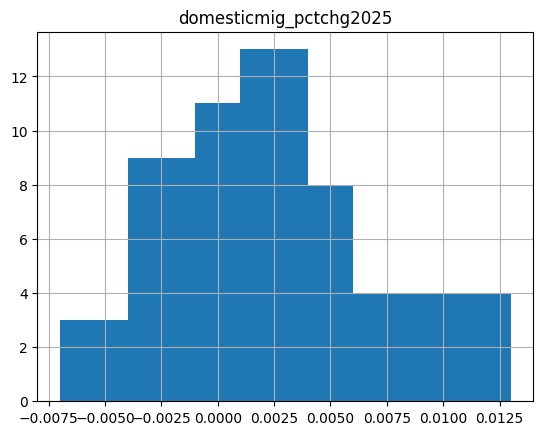

In [22]:
print(net_domesticmigr_df["domesticmig_pctchg2025"].describe())
bin_cutoff_list = [
    -0.007, -0.006, -0.004, -0.001, 0.001, 0.004, 0.006, 0.013
]
net_domesticmigr_df.hist(
    column="domesticmig_pctchg2025", bins=bin_cutoff_list
)

In [23]:
# Add cat_label, fill_color, and label_color columns to net_domesticmigr_df
fig3_fill_color_list = [
    "#de2d26", "#fc9272", "#fee0d2", "white", "#deebf7", "#9ecae1", "#3182bd"
]
fig3_label_color_list = [
    "white", "black", "black", "black", "black", "black", "white"
]
net_domesticmigr_plot_df = net_domesticmigr_df.copy()
net_domesticmigr_plot_df["cat_label"] = ""
net_domesticmigr_plot_df["fill_color"] = ""
net_domesticmigr_plot_df["label_color"] = ""
for bin in range(len(bin_cutoff_list) - 1):
    bin_min = bin_cutoff_list[bin]
    bin_max = bin_cutoff_list[bin + 1]
    if bin == 0:
        net_domesticmigr_plot_df.loc[
            net_domesticmigr_plot_df["domesticmig_pctchg2025"] < bin_max,
            "cat_label"
        ] = f"Less than {(bin_max * 100):.1f}%"
        net_domesticmigr_plot_df.loc[
            net_domesticmigr_plot_df["domesticmig_pctchg2025"] < bin_max,
            "fill_color"
        ] = fig3_fill_color_list[bin]
        net_domesticmigr_plot_df.loc[
            net_domesticmigr_plot_df["domesticmig_pctchg2025"] < bin_max,
            "label_color"
        ] = fig3_label_color_list[bin]
    elif ((bin > 0) and (bin < len(bin_cutoff_list) - 2)):
        net_domesticmigr_plot_df.loc[
            (net_domesticmigr_plot_df["domesticmig_pctchg2025"] >= bin_min) &
            (net_domesticmigr_plot_df["domesticmig_pctchg2025"] < bin_max),
            "cat_label"
        ] = f"{(bin_min * 100):.1f}% to {(bin_max * 100):.1f}%"
        net_domesticmigr_plot_df.loc[
            (net_domesticmigr_plot_df["domesticmig_pctchg2025"] >= bin_min) &
            (net_domesticmigr_plot_df["domesticmig_pctchg2025"] < bin_max),
            "fill_color"
        ] = fig3_fill_color_list[bin]
        net_domesticmigr_plot_df.loc[
            (net_domesticmigr_plot_df["domesticmig_pctchg2025"] >= bin_min) &
            (net_domesticmigr_plot_df["domesticmig_pctchg2025"] < bin_max),
            "label_color"
        ] = fig3_label_color_list[bin]
    elif bin == len(bin_cutoff_list) - 2:
        net_domesticmigr_plot_df.loc[
            net_domesticmigr_plot_df["domesticmig_pctchg2025"] >= bin_min,
            "cat_label"
        ] = f"Greater than {(bin_min * 100):.1f}%"
        net_domesticmigr_plot_df.loc[
            net_domesticmigr_plot_df["domesticmig_pctchg2025"] >= bin_min,
            "fill_color"
        ] = fig3_fill_color_list[bin]
        net_domesticmigr_plot_df.loc[
            net_domesticmigr_plot_df["domesticmig_pctchg2025"] >= bin_min,
            "label_color"
        ] = fig3_label_color_list[bin]

net_domesticmigr_plot_df

,state_str,state_abbrev,popestimate2024,domesticmig2025,domesticmig_pctchg2025,popestimate2023,domesticmig2024,domesticmig_pctchg2024,netdomesticmig_rank_2025,netdomesticmig_rank_2024,cat_label,fill_color,label_color
0,South Carolina,SC,5490316,66622,0.012134,5390798,66367,0.012311,1,1,Greater than 0.6%,#3182bd,white
1,Idaho,ID,2000872,19915,0.009953,1970497,15975,0.008107,2,2,Greater than 0.6%,#3182bd,white
2,North Carolina,NC,11052061,84064,0.007606,10871849,83059,0.007640,3,4,Greater than 0.6%,#3182bd,white
3,Delaware,DE,1050123,6855,0.006528,1035354,8040,0.007765,4,3,Greater than 0.6%,#3182bd,white
4,Tennessee,TN,7251291,42389,0.005846,7153029,46496,0.006500,5,5,0.4% to 0.6%,#9ecae1,black
5,Montana,MT,1137557,6348,0.005580,1130612,5263,0.004655,6,8,0.4% to 0.6%,#9ecae1,black
6,Maine,ME,1408438,7406,0.005258,1401992,5189,0.003701,7,12,0.4% to 0.6%,#9ecae1,black
7,Arkansas,AR,3096080,14475,0.004675,3069856,13919,0.004534,8,10,0.4% to 0.6%,#9ecae1,black
8,New Hampshire,NH,1408518,6554,0.004653,1401530,5425,0.003871,9,11,0.4% to 0.6%,#9ecae1,black
9,Nevada,NV,3253543,14914,0.004584,3211077,16473,0.005130,10,6,0.4% to 0.6%,#9ecae1,black


In [24]:
fig3_title = (
    "Figure 3. 2025 net domestic migration as percent of 2024 population"
)
# fig3_title = ""
output_file(
    "./images/fig3_net_domestic_migration_2025.html",
    title=fig3_title, mode='inline'
)
output_notebook()

# Download U.S. states shape files from US Census Bureau
# https://www.census.gov/geographies/mapping-files/2018/geo/carto-boundary-file.html
us_shapefile_path = (
    "https://github.com/OpenSourceEcon/NC-TaxTriggers/raw/main/data/" +
    "cb_2018_us_state_20m/cb_2018_us_state_20m.shp"
)
gdf = gpd.GeoDataFrame.from_file(us_shapefile_path)
gdf_json = gdf.to_json()
gjson = json.loads(gdf_json)

# Remove Puerto Rico from data
del(gjson["features"][7])

# Alaska
# Fix positive longitudes
min_lat_ak = 180  # initial value that will be adjusted
min_abs_lon_ak = 180  # initial value that will be adjusted
coords_list = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_ak = np.minimum(min_lat_ak, point[1])
        if point[0] > 0:
            gjson["features"][24]["geometry"][
                "coordinates"
            ][ind_isl][0][ind_pnt][0] = -180 - (180 - point[0])
        else:
            min_abs_lon_ak = np.minimum(min_abs_lon_ak, -point[0])

# Shrink the size of Alaska relative to its southestern most minimum lattitude
# and longitude
shrink_pct_ak = 0.65
coords_list_ak = gjson["features"][24]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_ak):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] - shrink_pct_ak * (point[0] +
                                                                min_abs_lon_ak)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - shrink_pct_ak * (point[1] -
                                                                min_lat_ak)

# Move Alaska closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-127, 44)
min_lat_ak_new = 44
min_abs_lon_ak_new = 127
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_ak -
                                                min_abs_lon_ak_new)
        gjson["features"][24]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_ak - min_lat_ak_new)

# Hawaii
list_ind_hi = 47
# Get minimum lattitude and minimum absolute longitude for Hawaii
min_lat_hi = 180  # initial value that will be adjusted
min_abs_lon_hi = 180  # initial value that will be adjusted
coords_list = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        min_lat_hi = np.minimum(min_lat_hi, point[1])
        min_abs_lon_hi = np.minimum(min_abs_lon_hi, -point[0])
# print("Minimum lattitude for Hawaii is", min_lat_hi)
# print("Minimum absolute longitude for Hawaii is", min_abs_lon_hi)

# Increase the size of Hawaii
incr_pct_hi = 0.4
coords_list_hi = gjson["features"][list_ind_hi]["geometry"]["coordinates"]
for ind_isl, island in enumerate(coords_list_hi):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + incr_pct_hi * (point[0] +
                                                              min_abs_lon_hi)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] + incr_pct_hi * (point[1] -
                                                              min_lat_hi)

# Move Hawaii closer to the mainland such that the minimum minimum absolute
# longitude and lattitude are (-125, 27)
min_lat_hi_new = 27.5
min_abs_lon_hi_new = 124.5
for ind_isl, island in enumerate(coords_list):
    for ind_pnt, point in enumerate(island[0]):
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][0] = point[0] + (min_abs_lon_hi -
                                                min_abs_lon_hi_new)
        gjson["features"][list_ind_hi]["geometry"][
            "coordinates"
        ][ind_isl][0][ind_pnt][1] = point[1] - (min_lat_hi - min_lat_hi_new)

# Add a state box around Delaware abbreviation DE
st_list_num = 2
de_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_de = [[
    [-75.4, 38.8],
    [-72.4, 38.3],
    [-72.4, 38.9],
    [-70.2, 38.9],
    [-70.2, 37.7],
    [-72.4, 37.7],
    [-72.4, 38.3]
]]
de_coord_list.append(new_box_de)
gjson["features"][st_list_num]["geometry"]["coordinates"] = de_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Washington, DC (District of Columbia) abbreviation DC
st_list_num = 35
dc_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_dc = [[
    [-77.0, 38.9],
    [-73.3, 35.5],
    [-73.3, 36.1],
    [-71.1, 36.1],
    [-71.1, 34.9],
    [-73.3, 34.9],
    [-73.3, 35.5]
]]
dc_coord_list.append(new_box_dc)
gjson["features"][st_list_num]["geometry"]["coordinates"] = dc_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Massachusetts abbreviation MD
st_list_num = 0
md_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_md = [[
    [-76.8, 39.3],
    [-72.7, 37.0],
    [-72.7, 37.6],
    [-70.5, 37.6],
    [-70.5, 36.4],
    [-72.7, 36.4],
    [-72.7, 37.0]
]]
md_coord_list.append(new_box_md)
gjson["features"][st_list_num]["geometry"]["coordinates"] = md_coord_list

# Add a state box around Massachusetts abbreviation MA
st_list_num = 29
ma_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ma = [[
    [-71.7, 42.2],
    [-68.5, 42.2],
    [-68.5, 42.8],
    [-66.3, 42.8],
    [-66.3, 41.6],
    [-68.5, 41.6],
    [-68.5, 42.2]
]]
ma_coord_list.append(new_box_ma)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ma_coord_list

# Add a state box around New Jersey abbreviation NJ
st_list_num = 34
nj_coord_list = [gjson["features"][st_list_num]["geometry"]["coordinates"]]
new_box_nj = [[
    [-74.4, 40.1],
    [-72.0, 39.7],
    [-72.0, 40.3],
    [-69.8, 40.3],
    [-69.8, 39.1],
    [-72.0, 39.1],
    [-72.0, 39.7]
]]
nj_coord_list.append(new_box_nj)
gjson["features"][st_list_num]["geometry"]["coordinates"] = nj_coord_list
gjson["features"][st_list_num]["geometry"]["type"] = "MultiPolygon"

# Add a state box around Rhode Island abbreviation RI
st_list_num = 50
ri_coord_list = gjson["features"][st_list_num]["geometry"]["coordinates"]
new_box_ri = [[
    [-71.5, 41.7],
    [-69.5, 40.4],
    [-69.5, 41.0],
    [-67.3, 41.0],
    [-67.3, 39.8],
    [-69.5, 39.8],
    [-69.5, 40.4]
]]
ri_coord_list.append(new_box_ri)
gjson["features"][st_list_num]["geometry"]["coordinates"] = ri_coord_list

# Merge the state domestic migration percent change data into gjson for each
# state
net_domesticmigr_plot_df
for ind_st, state in enumerate(gjson["features"]):
    st_abbrev = state["properties"]["STUSPS"]
    state["properties"]["netmigr_pct_cat"] = net_domesticmigr_plot_df[
        net_domesticmigr_plot_df["state_abbrev"]==st_abbrev
    ]["cat_label"].iloc[0]
    state["properties"]["net_migr_pct_chg"] = net_domesticmigr_plot_df[
        net_domesticmigr_plot_df["state_abbrev"]==st_abbrev
    ]["domesticmig_pctchg2025"].iloc[0]

fig3_cat_labels = [
    "Less than -0.6%", "-0.6% to -0.4%", "-0.4% to -0.1%", "-0.1% to 0.1%",
    "0.1% to 0.4%", "0.4% to 0.6%", "Greater than 0.6%"
]

source_shapes = {}
for category in fig3_cat_labels:
    source_shapes[category] = {"type": "FeatureCollection", "features": []}

for item in gjson["features"]:
    source_shapes[
        item["properties"]["netmigr_pct_cat"]
    ]['features'].append(item)

TOOLS = "pan, box_zoom, wheel_zoom, hover, save, reset, help"

fig3 = figure(
    title=fig3_title,
    height=500,
    width=950,
    tools=TOOLS,
    min_border = 0,
    x_axis_location = None, y_axis_location = None,
    toolbar_location="right"
)
fig3.toolbar.logo = None
fig3.grid.grid_line_color = None

cmap = CategoricalColorMapper(
    palette=fig3_fill_color_list, factors=fig3_cat_labels
)
for category in fig3_cat_labels:
    source_shape_1 = GeoJSONDataSource(
        geojson = json.dumps(source_shapes[category])
    )
    fig3.patches(
        'xs', 'ys', source=source_shape_1, fill_alpha=0.7,
        fill_color = {'field': 'netmigr_pct_cat', 'transform': cmap},
        line_color ='black', line_width=1.0, line_alpha=0.3,
        hover_line_color="black", hover_line_width=3.0, legend_label=category)

    hover = fig3.select_one(HoverTool)
    hover.point_policy = "follow_mouse"
    hover.tooltips = [
        ("State", "@NAME"),
        ("Pct chg category", "@netmigr_pct_cat"),
        ("2025 net domestic migration (%chg)", "@net_migr_pct_chg{0.00%}")
    ]

# Add 2-letter state abbreviation labels. See Bokeh documentation for labels at
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/annotations.html.
label_lon_lat =[
    ["AL",  -87.40, 32.10],
    ["AK", -135.00, 48.30],
    ["AZ", -112.40, 34.00],
    ["AR",  -93.20, 34.30],
    ["CA", -121.00, 37.00],
    ["CO", -106.50, 38.50],
    ["CT",  -73.40, 41.25],
    ["DE",  -72.10, 37.80],
    ["DC",  -73.00, 35.00],
    ["FL",  -82.40, 28.00],
    ["GA",  -84.20, 32.20],
    ["HI", -126.00, 28.00],
    ["ID", -115.00, 43.00],
    ["IL",  -89.60, 39.50],
    ["IN",  -86.90, 39.60],
    ["IA",  -94.40, 41.60],
    ["KS",  -99.50, 38.00],
    ["KY",  -86.00, 37.00],
    ["LA",  -93.00, 30.20],
    ["ME",  -70.00, 44.50],
    ["MD",  -72.40, 36.50],
    ["MA",  -68.20, 41.80],
    ["MI",  -85.40, 42.70],
    ["MN",  -95.30, 45.50],
    ["MS",  -90.60, 32.10],
    ["MO",  -93.50, 38.00],
    ["MT", -110.50, 46.50],
    ["NE", -100.50, 41.00],
    ["NV", -118.00, 39.00],
    ["NH",  -72.45, 42.70],
    ["NM", -107.00, 34.00],
    ["NJ",  -71.60, 39.30],
    ["NY",  -76.00, 42.50],
    ["NC",  -79.20, 35.00],
    ["ND", -101.50, 46.80],
    ["OH",  -83.80, 39.90],
    ["OK",  -98.00, 35.00],
    ["OR", -121.50, 43.50],
    ["PA",  -78.50, 40.40],
    ["RI",  -69.00, 40.00],
    ["SC",  -81.50, 33.30],
    ["SD", -101.00, 44.00],
    ["TN",  -87.10, 35.40],
    ["TX", -100.00, 31.00],
    ["UT", -112.50, 39.00],
    ["VT",  -73.20, 44.10],
    ["VA",  -79.00, 37.10],
    ["WA", -121.00, 47.00],
    ["WV",  -81.90, 38.00],
    ["WI",  -90.40, 44.00],
    ["WY", -108.50, 42.50]
]
# Add text color element to each state in list based on tax type
for i, state in enumerate(label_lon_lat):
    label_lon_lat[i].append(
        net_domesticmigr_plot_df[
            net_domesticmigr_plot_df["state_abbrev"]==state[0]
        ]["label_color"].iloc[0]
    )
label_abbrev = [state[0] for state in label_lon_lat]
label_lon = [state[1] for state in label_lon_lat]
label_lat = [state[2] for state in label_lon_lat]
label_color = [state[3] for state in label_lon_lat]
state_cds = ColumnDataSource(data=dict(
    lon=label_lon,
    lat=label_lat,
    abbrev=label_abbrev,
    txtcolor=label_color
))

state_labels = LabelSet(
    x='lon', y='lat', text='abbrev', text_font_size="8pt",
    text_color='txtcolor', text_font_style="bold", x_offset=0, y_offset=0,
    source=state_cds
)

fig3.add_layout(state_labels)

# Legend properties
fig3.legend.click_policy = 'mute'
fig3.legend.location = "center_left"

note_text_list3 = [
    (
        '  Source: Richard W. Evans (@RickEcon), updated May 6, 2025. ' +
        'Data are from US Census Bureau, U-Haul, United Van Lines.'
    )
]
for note_text in note_text_list3:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig3.add_layout(caption, 'below')

show(fig3)

Loading BokehJS ...

## 3. Create Figures 4 and 5

### 3.1. Figure 4. Rainy Day Fund and Total Reserves as Percentages of General-Fund Expenditures, North Carolina and 50-State Median: 2000-2025

Get the Pew state rainy day fund data. This does not include District of Columbia. The 2024 data is now final. The 2025 data is labeled as "Preliminary" which means projected based on enacted legislation. See Page Forrest and Justin Theal, "[Strength of State Rainy Day Fundas Declines as Budgets Tighten](https://www.pew.org/en/research-and-analysis/articles/2026/03/24/strength-of-state-rainy-day-funds-declines-as-budgets-tighten)," Article, Pew (Mar. 24, 2026).

In [25]:
# Read in the Pew data on rainy day funds by year and state from worksheet
rain_totbal_path = (
    "https://github.com/OpenSourceEcon/NC-TaxTriggers/blob/main/data/" +
    "Pew_ReservesData_2025.csv?raw=true"
)

In [26]:
# Create a DataFrame of just the rainy day funds in $ by state and by year
rain_dol_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
rain_dol_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,2500000,7500000,261000000,68000000,104000000,157000000,418700000,676600000,248000000,178700000,...,530174640,766196710,783700000,848200000,968107090,1.184300e+09,1.429000e+09,1.978000e+09,2.681700e+09,2.750100e+09
Alaska,2734200000,2994800000,2114000000,2092500000,2155100000,2274200000,2267100000,3015200000,5601200000,8897900000,...,7108900000,4641300000,2532500000,2288000000,1378900000,1.059900e+09,2.625800e+09,2.453500e+09,2.557400e+09,2.730100e+09
Arizona,407800000,391500000,65000000,13800000,13500000,160800000,501600000,677000000,218600000,2700000,...,460800000,461446000,457800000,742960000,978500000,9.747000e+08,9.822000e+08,1.424000e+09,1.476800e+09,1.545300e+09
Arkansas,0,0,0,0,0,0,0,0,0,0,...,0,123400000,126600000,152500000,184985000,2.100000e+08,1.212000e+09,1.529600e+09,1.814900e+09,1.814900e+09
California,8665500000,1563800000,0,0,0,9112300000,10071400000,3014800000,0,0,...,7223600000,11250800000,20842000000,23001300000,20632100000,5.245310e+10,7.621680e+10,6.757110e+10,4.817149e+10,3.589148e+10
Colorado,583400000,0,0,0,121800000,0,0,267000000,283500000,443750000,...,512724680,614463790,1365993460,1262000000,1823300000,3.178000e+09,1.612200e+09,2.427300e+09,3.153500e+09,2.334000e+09
Connecticut,564000000,594700000,0,0,302200000,666100000,1112500000,1381700000,1381700000,1381718000,...,235600000,212900000,1185300000,2134902580,3074600000,3.112000e+09,3.313400e+09,3.315800e+09,4.105100e+09,4.326500e+09
Delaware,114000000,126000000,128000000,129000000,136500000,148200000,161100000,175400000,182800000,186400000,...,214700000,221100000,231600000,240400000,252400000,2.524000e+08,2.803000e+08,3.164000e+08,3.288000e+08,3.487000e+08
Florida,1666100000,894000000,941000000,958900000,966400000,988200000,1069300000,1236800000,1344800000,273900000,...,1353700000,1384400000,1416500000,1483000000,1574200000,1.674200e+09,2.730200e+09,3.140200e+09,4.140400e+09,4.440600e+09


In [27]:
# Create a DataFrame of just the rainy day funds balances as a percent of
# general fund expenditures by state and by year
rain_pct_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
rain_pct_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,0.00048,0.00144,0.04901,0.01243,0.01897,0.02594,0.06015,0.08487,0.02880,0.02310,...,0.06790,0.09383,0.09435,0.09806,0.10400,0.12172,0.13413,0.14703,0.21011,0.19429
Alaska,1.20891,1.31738,0.88382,0.83844,0.92928,0.74449,0.69817,0.54775,1.02537,1.55229,...,1.29855,1.03188,0.56414,0.46802,0.28699,0.22861,0.48432,0.32143,0.39561,0.42384
Arizona,0.06783,0.06145,0.01025,0.00229,0.00207,0.02131,0.05721,0.06637,0.02178,0.00031,...,0.04844,0.04789,0.04667,0.06928,0.08671,0.07170,0.07620,0.09085,0.08528,0.09512
Arkansas,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.02307,0.02304,0.02711,0.03217,0.03560,0.20721,0.25391,0.29263,0.28755
California,0.13032,0.02004,0.00000,0.00000,0.00000,0.11418,0.10996,0.02973,0.00000,0.00000,...,0.06311,0.09431,0.16706,0.16384,0.14104,0.32353,0.34289,0.34618,0.23422,0.15366
Colorado,0.09736,0.00000,0.00000,0.00000,0.02141,0.00000,0.00000,0.03789,0.03811,0.06008,...,0.05012,0.05894,0.12180,0.09817,0.14339,0.23846,0.09043,0.12757,0.18689,0.12660
Connecticut,0.05168,0.04975,0.00000,0.00000,0.02385,0.04862,0.07645,0.08952,0.08467,0.08222,...,0.01312,0.01201,0.06344,0.11074,0.16044,0.15517,0.15983,0.14891,0.18396,0.18463
Delaware,0.05076,0.05187,0.05216,0.05257,0.05345,0.05251,0.05065,0.05174,0.05343,0.05656,...,0.05486,0.05385,0.05624,0.05471,0.05592,0.05589,0.05542,0.05399,0.05276,0.05035
Florida,0.08980,0.04455,0.04910,0.04674,0.04510,0.04043,0.04110,0.04383,0.04854,0.01158,...,0.04639,0.04566,0.04450,0.04459,0.04789,0.04616,0.07159,0.06405,0.07526,0.08349


In [28]:
# Create a DataFrame of just the total balances and reserves in $ by state and
# by year
totbal_dol_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
        44, 45, 46, 47, 48, 49, 50, 51, 52
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
totbal_dol_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,103600000,74300000,280200000,180500000,450600000,821000000,1368139040,1191400000,467000000,284100000,...,715015640,916096710,1376769670,1.822575e+09,1.788355e+09,3.004700e+09,4.852300e+09,5.214485e+09,5.757200e+09,4.897600e+09
Alaska,2734200000,2994800000,2114000000,2092500000,2181600000,2282800000,2267100000,3015200000,5601200000,7447100000,...,7108900000,4641300000,2532500000,2.288000e+09,1.378900e+09,1.059900e+09,3.264500e+09,2.453500e+09,2.557400e+09,2.730100e+09
Arizona,611200000,404740000,65700000,206000000,373800000,799770000,1548100000,1054950000,219600000,-478030000,...,744600000,612346000,907400000,1.700160e+09,1.351000e+09,1.869300e+09,5.691600e+09,3.951233e+09,4.066300e+09,3.966400e+09
Arkansas,0,0,0,0,0,0,0,0,0,0,...,177400000,123400000,126600000,4.479000e+08,1.881850e+08,1.155700e+09,2.810200e+09,2.690700e+09,2.513300e+09,2.029700e+09
California,9139000000,3037000000,-2133300000,1607300000,3488800000,9633600000,10816300000,3900100000,2375700000,-5854700000,...,8203500000,12415539000,22226463000,2.617630e+10,2.380720e+10,5.672964e+10,8.049320e+10,7.814030e+10,6.607209e+10,5.389206e+10
Colorado,798300000,469500000,137600000,224900000,346400000,335500000,908800000,516000000,327000000,443750000,...,512724680,614463790,1365993460,1.262000e+09,1.823300e+09,3.178000e+09,3.201800e+09,2.427300e+09,3.153500e+09,2.334000e+09
Connecticut,564000000,594700000,0,0,302200000,666100000,1112500000,1381700000,1382000000,1382000000,...,235600000,212900000,1185300000,2.505500e+09,3.074600e+09,3.112000e+09,3.313400e+09,3.315800e+09,4.506097e+09,4.706600e+09
Delaware,338000000,510000000,481700000,464100000,646000000,701300000,690600000,590900000,526000000,378500000,...,568000000,475000000,749800000,9.475000e+08,9.594000e+08,1.833400e+09,2.605400e+09,3.039530e+09,3.156380e+09,2.925320e+09
Florida,2155900000,1382700000,1925100000,1641300000,3423600000,4558800000,6059300000,4670400000,1665700000,905300000,...,3245500000,2898900000,3062400000,3.972700e+09,7.926400e+09,1.547600e+10,2.553330e+10,2.439230e+10,2.054570e+10,1.821370e+10


In [29]:
# Create a DataFrame of just the total balances and reserves as a percent of
# general fund expenditures by state and by year
totbal_pct_df = pd.read_csv(
    rain_totbal_path,
    skiprows=5,
    skipfooter=4,
    index_col=0,
    usecols=[
        0, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
        70, 71, 72, 73, 74, 75, 76, 77, 78
    ],
    names=[
        'state', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
        '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
        '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
        '2025'
    ]
)
totbal_pct_df

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
state,,,,,,,,,,,,,,,,,,,,,
Alabama,0.01986,0.01425,0.05262,0.03298,0.08218,0.13567,0.19653,0.14945,0.05422,0.03673,...,0.09157,0.11218,0.16575,0.21072,0.19212,0.30881,0.45546,0.38760,0.45108,0.34600
Alaska,1.20891,1.31738,0.88382,0.83844,0.94071,0.74731,0.69817,0.54775,1.02537,1.29919,...,1.29855,1.03188,0.56414,0.46802,0.28699,0.22861,0.60213,0.32143,0.39561,0.42384
Arizona,0.10166,0.06353,0.01037,0.03419,0.05737,0.10600,0.17655,0.10342,0.02188,-0.05460,...,0.07828,0.06355,0.09251,0.15854,0.11972,0.13750,0.44157,0.25209,0.23482,0.24416
Arkansas,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.03418,0.02307,0.02304,0.07961,0.03273,0.19589,0.48044,0.44664,0.40523,0.32159
California,0.13744,0.03891,-0.02779,0.02074,0.04570,0.12072,0.11809,0.03846,0.02307,-0.06438,...,0.07167,0.10408,0.17816,0.18646,0.16274,0.34990,0.36213,0.40033,0.32125,0.23072
Colorado,0.13322,0.07039,0.02058,0.03804,0.06089,0.05488,0.14088,0.07323,0.04395,0.06008,...,0.05012,0.05894,0.12180,0.09817,0.14339,0.23846,0.17959,0.12757,0.18689,0.12660
Connecticut,0.05168,0.04975,0.00000,0.00000,0.02385,0.04862,0.07645,0.08952,0.08468,0.08223,...,0.01312,0.01201,0.06344,0.12996,0.16044,0.15517,0.15983,0.14891,0.20193,0.20085
Delaware,0.15049,0.20996,0.19630,0.18911,0.25297,0.24849,0.21714,0.17431,0.15373,0.11485,...,0.14513,0.11568,0.18207,0.21562,0.21254,0.40595,0.51511,0.51861,0.50647,0.42241
Florida,0.11620,0.06891,0.10044,0.08001,0.15978,0.18653,0.23292,0.16552,0.06012,0.03826,...,0.11122,0.09560,0.09621,0.11944,0.24114,0.42671,0.66953,0.49749,0.37344,0.34243


In [30]:
rain_pct_50_df = rain_pct_df.loc["50-state", :].to_frame().reset_index()
rain_pct_50_df.rename(
    columns = {"index":"year", "50-state":"fraction"}, inplace = True
)
rain_pct_50_df["percent"] = 100 * rain_pct_50_df["fraction"]
rain_pct_50_df["series"] = "50-state median Rainy Day Fund"

rain_pct_nc_df = rain_pct_df.loc["North Carolina", :].to_frame().reset_index()
rain_pct_nc_df = rain_pct_nc_df.rename(
    columns = {"index":"year", "North Carolina":"fraction"}
)
rain_pct_nc_df["percent"] = 100 * rain_pct_nc_df["fraction"]
rain_pct_nc_df["series"] = "North Carolina Rainy Day Fund"

totbal_pct_50_df = \
    totbal_pct_df.loc["50-state", :].to_frame().reset_index()
totbal_pct_50_df = totbal_pct_50_df.rename(
    columns = {"index":"year", "50-state":"fraction"}
)
totbal_pct_50_df["percent"] = 100 * totbal_pct_50_df["fraction"]
totbal_pct_50_df["series"] = "50-state median total reserve balances"

totbal_pct_nc_df = totbal_pct_df.loc[
    "North Carolina", :
].to_frame().reset_index()
totbal_pct_nc_df = totbal_pct_nc_df.rename(
    columns = {'index':'year', "North Carolina":"fraction"}
)
totbal_pct_nc_df["percent"] = 100 * totbal_pct_nc_df["fraction"]
totbal_pct_nc_df["series"] = "North Carolina total reserve balances"

# Merge the four DataFrames to save the joint dataframe as a .csv
fig4_source_df = rain_pct_50_df[['year', 'percent']].rename(
    columns={'percent':'rain_50m_pct'}
)
fig4_source_df = pd.merge(
    fig4_source_df,
    rain_pct_nc_df[['year', 'percent']].rename(
        columns={'percent':'rain_nc_pct'}
    ),
    on='year', how='inner'
)
fig4_source_df = pd.merge(
    fig4_source_df,
    totbal_pct_50_df[['year', 'percent']].rename(
        columns={'percent':'totbal_50m_pct'}
    ),
    on='year', how='inner'
)
fig4_source_df = pd.merge(
    fig4_source_df,
    totbal_pct_nc_df[['year', 'percent']].rename(
        columns={'percent':'totbal_nc_pct'}
    ),
    on='year', how='inner'
)
# Set zeros to NaN
fig4_source_df = fig4_source_df.replace(0, np.nan)

fig4_source_df.to_csv('./data/fig4_source.csv', index=False)

fig4_source_df

,year,rain_50m_pct,rain_nc_pct,totbal_50m_pct,totbal_nc_pct
0,2000,4.127,0.271,8.767,0.271
1,2001,4.614,1.171,7.148,1.171
2,2002,1.656,NaN,2.887,0.028
3,2003,0.722,1.083,2.656,2.891
4,2004,1.844,1.816,5.247,3.784
5,2005,2.460,1.979,9.017,5.007
6,2006,4.553,3.685,11.802,8.076
7,2007,4.739,4.215,11.328,10.758
8,2008,4.835,3.833,8.292,6.752
9,2009,2.728,0.763,4.583,1.232


In [31]:
# Create Bokeh plot Fig 4: North Carolina Rainy Day fund and total reserves as
# a percentage of general fund expenditures: 2000-2025
fig4_title_lst = [
    ("Figure 4. North Carolina Rainy Day fund and total reserves as a"),
    ("percentage of general fund expenditures: 2000-2025"),
]
# fig4_title_lst = []
fig4_title_short = "Figure 4. NC Rainy Day fund and total reserves"
filename_fig4 = "fig4_nc_raintotbal_tseries.html"
output_file(
    os.path.join(image_dir, filename_fig4),
    title=fig4_title_short,
    mode="inline",
)
output_notebook()

# Format the tooltip
tooltips_fig4 = [
    ("Series:", "@series"),
    ("Year:", "@year"),
    ("Pct. of Gen. Fund Exps.:", "@fraction{0.0%}")
]

min_year = 2000
max_year = 2025
min_pct = 2.0
max_pct = 0.0
pct_buffer = 0.05
fig4_height = 500
fig4_width = 800

var_list = [rain_pct_nc_df, rain_pct_50_df, totbal_pct_nc_df, totbal_pct_50_df]
color_list = ["#3477A5", "#D5AB53", "#3477A5", "#D5AB53"]
marker_list = ["circle", "circle", "square", "square"]
legend_label_list = [
    "Rainy day fund, North Carolina",
    "Rainy day fund, 50-state median",
    "Total balances, North Carolina",
    "Total balances, 50-state median"
]
cds_list = []

for k, df in enumerate(var_list):
    min_pct = np.minimum(min_pct, df["percent"].min())
    max_pct = np.maximum(max_pct, df["percent"].max())
    cds_list.append(ColumnDataSource(df))

fig4 = figure(
    height=fig4_height,
    width=fig4_width,
    x_axis_label='Year',
    x_range=(min_year - 1, max_year + 0.99),
    y_axis_label='Percent of general fund expenditures',
    y_range=(min_pct - pct_buffer * (max_pct - min_pct),
             max_pct + pct_buffer * (max_pct - min_pct)),
    tools=["save", "help"],
    toolbar_location="right"
)
fig4.toolbar.logo = None

# Turn off any pan, drag, or scrolling ability
fig4.toolbar.active_drag = None
fig4.toolbar.active_scroll = None
fig4.toolbar.active_tap = None

# Set title font size and axes font sizes
fig4.xaxis.axis_label_text_font_size = '12pt'
fig4.xaxis.major_label_text_font_size = '12pt'
fig4.xaxis.major_label_text_color = '#434244'
fig4.yaxis.axis_label_text_font_size = '12pt'
fig4.yaxis.major_label_text_font_size = '12pt'
fig4.yaxis.major_label_text_color = '#434244'

# Modify tick intervals for X-axis and Y-axis
fig4.xaxis.ticker = SingleIntervalTicker(interval=2, num_minor_ticks=2)
fig4.xaxis.axis_line_color = '#434244'
fig4.xaxis.major_tick_line_color = '#434244'
fig4.xaxis.minor_tick_line_color = '#434244'
fig4.xgrid.ticker = SingleIntervalTicker(interval=2)
fig4.yaxis.ticker = SingleIntervalTicker(interval=10, num_minor_ticks=5)
fig4.yaxis.axis_line_color = '#434244'
fig4.yaxis.major_tick_line_color = '#434244'
fig4.yaxis.minor_tick_line_color = '#434244'
fig4.ygrid.ticker = SingleIntervalTicker(interval=10)

# Create lines and markers for time series
for k, yvar in enumerate(var_list):
    fig4.line(x='year', y='percent', source=cds_list[k], color=color_list[k],
              line_width=4, alpha=0.7)
    fig4.scatter(x='year', y='percent', source=cds_list[k], size=10,
                 line_width=1, line_color='black', fill_color=color_list[k],
                 marker=marker_list[k], line_alpha=0.7, fill_alpha=0.7,
                 legend_label=legend_label_list[k])

fig4.segment(x0=2024.4, y0=min_pct - pct_buffer * (max_pct - min_pct),
             x1=2024.4, y1=max_pct + pct_buffer * (max_pct - min_pct),
             color='#434244', line_dash='6 2', line_width=2)

label_projected = Label(
    x=2024.5, y=20.5, x_units='data', y_units='data', text='Prelim.',
    text_font_size='9pt', text_color='#434244'
)
fig4.add_layout(label_projected)

# Add legend
fig4.legend.location = 'top_center'
fig4.legend.border_line_width = 1
fig4.legend.border_line_color = '#434244'
fig4.legend.border_line_alpha = 1
fig4.legend.label_text_font_size = '12pt'
fig4.legend.label_text_color = '#434244'

# Add title and subtitle to the plot doing reverse loop through items in
# fig_title_lst
for title_line_str in fig4_title_lst[::-1]:
    fig4.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="15pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list4 = [
    (
        'Source: Richard W. Evans (@RickEcon), Forrest and Theal (2026), ' +
        'Pew Charitable Trusts.'
    )
]
for note_text in note_text_list4:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig4.add_layout(caption, 'below')

# Add the HoverTool to the figure
fig4.add_tools(
    HoverTool(
        tooltips=tooltips_fig4,
        visible=False
    )
)

show(fig4)

Loading BokehJS ...

### 3.2. Figure 5. Estimated 2025 Rainy Day Fund Balances and Total Reserves and Balances as Percentages of General-Fund Expenditures

In [32]:
rain_pct_2025_df = rain_pct_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
rain_pct_2025_df = rain_pct_2025_df.rename(
    columns = {"index": "state", "2025": "rain_frac"}
)
rain_pct_2025_df["rain_pct"] = 100 * rain_pct_2025_df["rain_frac"]
rain_pct_2025_df = rain_pct_2025_df.drop('rain_frac', axis=1)

rain_dol_2025_df = rain_dol_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
rain_dol_2025_df = rain_dol_2025_df.rename(
    columns = {"index": "state", "2025": "rain_dol"}
)

totbal_pct_2025_df = \
    totbal_pct_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
totbal_pct_2025_df = totbal_pct_2025_df.rename(
    columns = {"index": "state", "2025": "totbal_frac"}
)
totbal_pct_2025_df["totbal_pct"] = 100 * totbal_pct_2025_df["totbal_frac"]
totbal_pct_2025_df = totbal_pct_2025_df.drop('totbal_frac', axis=1)

totbal_dol_2025_df = \
    totbal_dol_df.loc[:'Wyoming', '2025'].to_frame().reset_index()
totbal_dol_2025_df = totbal_dol_2025_df.rename(
    columns = {"index": "state", "2025": "totbal_dol"}
)

# Merge the four DataFrames
rain_totbal_pct_dol_2025_df = rain_pct_2025_df.copy()
rain_totbal_pct_dol_2025_df = pd.merge(
    rain_totbal_pct_dol_2025_df, rain_dol_2025_df, on='state', how='inner'
)
rain_totbal_pct_dol_2025_df["rain_color"] = "#D5AB53"
rain_totbal_pct_dol_2025_df.loc[
    rain_totbal_pct_dol_2025_df["state"]=="North Carolina", "rain_color"
] = "#EED17E"
rain_totbal_pct_dol_2025_df = pd.merge(
    rain_totbal_pct_dol_2025_df, totbal_pct_2025_df, on='state', how='inner'
)
rain_totbal_pct_dol_2025_df = pd.merge(
    rain_totbal_pct_dol_2025_df, totbal_dol_2025_df, on='state', how='inner'
)
rain_totbal_pct_dol_2025_df["totbal_color"] = "#3477A5"
rain_totbal_pct_dol_2025_df.loc[
    rain_totbal_pct_dol_2025_df["state"]=="North Carolina", "totbal_color"
] = "#74AAC7"

# Create a new variable that is totbal_pct - rain_pct
rain_totbal_pct_dol_2025_df["totbal_rain_pct_dif"] = (
    rain_totbal_pct_dol_2025_df["totbal_pct"] -
    rain_totbal_pct_dol_2025_df["rain_pct"]
)

# Sort by total reserves balances percent
rain_totbal_pct_dol_2025_sorted_df = rain_totbal_pct_dol_2025_df.sort_values(
    by=['totbal_pct', 'rain_pct', 'state'], ascending=[True, True, True]
)

rain_totbal_pct_dol_2025_sorted_df.to_csv(
    os.path.join(data_dir, "fig5_source.csv"), index=False
)
rain_totbal_pct_dol_2025_sorted_df

,state,rain_pct,rain_dol,rain_color,totbal_pct,totbal_dol,totbal_color,totbal_rain_pct_dif
46,Washington,3.511,1.250400e+09,#D5AB53,7.578,2.698600e+09,#3477A5,4.067
19,Maryland,7.924,2.184900e+09,#D5AB53,8.907,2.455791e+09,#3477A5,0.983
17,Louisiana,9.416,1.226600e+09,#D5AB53,9.423,1.227598e+09,#3477A5,0.007
23,Mississippi,9.577,6.733000e+08,#D5AB53,9.665,6.795000e+08,#3477A5,0.088
12,Illinois,4.264,2.357113e+09,#D5AB53,9.868,5.455776e+09,#3477A5,5.604
38,Rhode Island,6.297,3.525000e+08,#D5AB53,10.410,5.827130e+08,#3477A5,4.113
13,Indiana,7.989,1.826100e+09,#D5AB53,10.949,2.502600e+09,#3477A5,2.960
28,New Hampshire,12.191,2.450000e+08,#D5AB53,12.191,2.450000e+08,#3477A5,0.000
5,Colorado,12.660,2.334000e+09,#D5AB53,12.660,2.334000e+09,#3477A5,0.000
45,Virginia,12.994,4.749500e+09,#D5AB53,13.031,4.762900e+09,#3477A5,0.037


In [33]:
# Create Bokeh plot Fig 5: State 2025 Rainy day Fund Balances and Total Fund
# Balances as Percent of General Fund Expenditures
fig5_title_lst = [
    ("Figure 5. State 2025 Rainy day Fund Balances and Total"),
    ("Fund Balances as Percent of General Fund Expenditures")
]
# fig5_title_lst = []
fig5_title_short = "Figure 5. State 2025 Rainy Day fund and Total Reserves"
filename_fig5 = "fig5_rain_totbal_pct_2025.html"
output_file(
    os.path.join(image_dir, filename_fig5),
    title=fig5_title_short,
    mode="inline",
)
output_notebook()

states = rain_totbal_pct_dol_2025_sorted_df['state'].tolist()
legend_label_list_fig5 = ["Rainy day fund", "Total reserves and balances"]
rain_totbal_pct_dol_2025_cds = \
    ColumnDataSource(rain_totbal_pct_dol_2025_sorted_df)

min_pct = rain_totbal_pct_dol_2025_sorted_df['rain_pct'].min()
max_pct = rain_totbal_pct_dol_2025_sorted_df['totbal_pct'].max()
pct_buffer = 0.05
fig5_height = 900
fig5_width = 550

fig5 = figure(
    height=fig5_height,
    width=fig5_width,
    y_range=states,
    x_axis_label='Percentage of general fund expenditures',
    x_range=(min_pct - pct_buffer * (max_pct - min_pct),
             max_pct + pct_buffer * (max_pct - min_pct)),
    tools=["save", "help"],
    toolbar_location="right"
)
fig5.toolbar.logo = None

# Turn off any pan, drag, or scrolling ability
fig5.toolbar.active_drag = None
fig5.toolbar.active_scroll = None
fig5.toolbar.active_tap = None

# Set title font size and axes font sizes
fig5.xaxis.axis_label_text_font_size = '11pt'
fig5.xaxis.major_label_text_font_size = '11pt'
fig5.xaxis.major_label_text_color = '#434244'
fig5.yaxis.axis_label_text_font_size = '9pt'
fig5.yaxis.major_label_text_font_size = '9pt'
fig5.yaxis.major_label_text_color = '#434244'

# Modify tick intervals for X-axis and Y-axis
fig5.xaxis.ticker = SingleIntervalTicker(interval=10, num_minor_ticks=5)
fig5.xaxis.axis_line_color = '#434244'
fig5.xaxis.major_tick_line_color = '#434244'
fig5.xaxis.minor_tick_line_color = '#434244'
fig5.xgrid.ticker = SingleIntervalTicker(interval=10)
fig5.yaxis.axis_line_color = '#434244'
fig5.yaxis.major_tick_line_color = '#434244'
fig5.yaxis.minor_tick_line_color = '#434244'

fig5.hbar_stack(
    ['rain_pct', 'totbal_rain_pct_dif'], y='state', height=0.9,
    color=['rain_color', 'totbal_color'],
    source=rain_totbal_pct_dol_2025_cds, legend_label=legend_label_list_fig5
)

# Add information on hover
tooltips_fig5 = [
    ('State', '@state'),
    ('Rainy day fund % exps.','@rain_pct{0.0}' + '%'),
    ('Total balances % exps.','@totbal_pct{0.0}' + '%'),
]
fig5.add_tools(HoverTool(tooltips=tooltips_fig5, visible=False))

# Add legend
fig5.legend.location = (190, 240)
fig5.legend.border_line_width = 1
fig5.legend.border_line_color = '#434244'
fig5.legend.border_line_alpha = 1
fig5.legend.label_text_color = '#434244'
fig5.legend.label_text_font_size = '11pt'
fig5.legend.label_text_color = '#434244'
fig5.y_range.range_padding = 0.02

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig5_title_lst[::-1]:
    fig5.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list5 = [
    ('Source: Richard W. Evans (@RickEcon), Forrest and Theal (2026), Pew'),
    ('        Charitable Trusts.'),
    (
        'Note: For states in which the blue bar is not visible for total ' +
        'balances'
    ),
    ('        and reserves, the value equals the rainy day fund balance'),
    ('        percentage.')
]
for note_text in note_text_list5:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig5.add_layout(caption, 'below')

show(fig5)

Loading BokehJS ...

## 4. Compute North Carolina tax liability in 2026, 2027, and 2028 for the forecast flat rates of 3.99%, 3.49% and 2.99%, respectively

### 4.0. Create plot of North Carolina flat individual income tax rates under current law and reform 

In [34]:
nc_indtax_dict = {
    "year": [
        2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
        2026, 2027, 2028
    ],
    "ind_inc_tax_rate_curr": [
        0.058, 0.0575, 0.0575, 0.05499, 0.05499, 0.0525, 0.0525, 0.0525,
        0.0499, 0.0475, 0.0450, 0.0425, 0.0399, 0.0349, 0.0299
    ],
    "ind_inc_tax_rate_ref": [
        np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan,
        np.nan, np.nan, np.nan, 0.0399, 0.0374, 0.0349
    ]
}
nc_indtax_df = pd.DataFrame(nc_indtax_dict)
# print(nc_indtax_df)

# Create Bokeh plot Fig 6: North Carolina individual income tax rates, current law versus proposed reform: 2014-2028
fig6_title_lst = [
    ("Figure 6. North Carolina individual income tax rates,"),
    ("current law versus proposed reform: 2014-2028"),
]
# fig6_title_lst = []
fig6_title_short = "Figure 6. NC indiv inc tax rates, current law vs reform"
filename_fig6 = "fig6_nc_indtax_tseries.html"
output_file(
    os.path.join(image_dir, filename_fig6),
    title=fig6_title_short,
    mode="inline",
)
output_notebook()

# # Format the tooltip
# tooltips_fig6 = [
#     ("Series:", "@series"),
#     ("Year:", "@year"),
#     ("Pct. of Gen. Fund Exps.:", "@fraction{0.0%}")
# ]

min_year = 2014
max_year = 2028
min_pct = 0.0
max_pct = 0.058
pct_buffer = 0.05
fig6_height = 500
fig6_width = 800

fig6 = figure(
    height=fig6_height,
    width=fig6_width,
    x_axis_label='Year',
    x_range=(min_year - 1, max_year + 0.99),
    y_axis_label='NC indiv. income tax rate',
    y_range=(min_pct - pct_buffer * (max_pct - min_pct),
             max_pct + pct_buffer * 2 * (max_pct - min_pct)),
    tools=["save", "help"],
    toolbar_location="right"
)
fig6.toolbar.logo = None

# Turn off any pan, drag, or scrolling ability
fig6.toolbar.active_drag = None
fig6.toolbar.active_scroll = None
fig6.toolbar.active_tap = None

# Set title font size and axes font sizes
fig6.xaxis.axis_label_text_font_size = '12pt'
fig6.xaxis.major_label_text_font_size = '12pt'
fig6.xaxis.major_label_text_color = '#434244'
fig6.yaxis.axis_label_text_font_size = '12pt'
fig6.yaxis.major_label_text_font_size = '12pt'
fig6.yaxis.major_label_text_color = '#434244'

# Modify tick intervals for X-axis and Y-axis
fig6.xaxis.ticker = SingleIntervalTicker(interval=2, num_minor_ticks=2)
fig6.xaxis.axis_line_color = '#434244'
fig6.xaxis.major_tick_line_color = '#434244'
fig6.xaxis.minor_tick_line_color = '#434244'
fig6.xgrid.ticker = SingleIntervalTicker(interval=2)
fig6.yaxis.ticker = SingleIntervalTicker(interval=0.01, num_minor_ticks=2)
fig6.yaxis.axis_line_color = '#434244'
fig6.yaxis.major_tick_line_color = '#434244'
fig6.yaxis.minor_tick_line_color = '#434244'
fig6.ygrid.ticker = SingleIntervalTicker(interval=0.01)

# Create lines and markers for time series
fig6.line(
    x='year', y='ind_inc_tax_rate_curr', source=ColumnDataSource(nc_indtax_df), color="black", line_width=4,
    alpha=0.7
)
fig6.scatter(
    x='year', y='ind_inc_tax_rate_curr', source=ColumnDataSource(nc_indtax_df), color="black", size=10,
    line_width=1, line_color='black', fill_color="black", marker="circle", line_alpha=0.7, fill_alpha=0.7,
    muted_alpha=0.1, legend_label="Current law"
)
fig6.line(
    x='year', y='ind_inc_tax_rate_ref', source=ColumnDataSource(nc_indtax_df), color="#3477A5", line_width=4,
    alpha=0.7
)
fig6.scatter(
    x='year', y='ind_inc_tax_rate_ref', source=ColumnDataSource(nc_indtax_df), color="#3477A5", size=12,
    line_width=1, line_color='black', fill_color="#3477A5", marker="diamond", line_alpha=0.7, fill_alpha=0.7,
    legend_label="Proposed reduced cuts"
)
fig6.segment(
    x0=2026.4, y0=min_pct - pct_buffer * (max_pct - min_pct),
    x1=2026.4, y1=max_pct + pct_buffer * 2 * (max_pct - min_pct),
    color='#434244', line_dash='6 2', line_width=2
)

label_projected = Label(
    x=2026.8, y=0.022, x_units='data', y_units='data', text='Projected',
    text_font_size='9pt', text_color='#434244'
)
fig6.add_layout(label_projected)

# Add legend
fig6.legend.location = 'top_right'
fig6.legend.border_line_width = 1
fig6.legend.border_line_color = '#434244'
fig6.legend.border_line_alpha = 1
fig6.legend.label_text_font_size = '12pt'
fig6.legend.label_text_color = '#434244'

# Add title and subtitle to the plot doing reverse loop through items in
# fig_title_lst
for title_line_str in fig6_title_lst[::-1]:
    fig6.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="15pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list6 = [
    ('Source: Richard W. Evans (@RickEcon), North Carolina Department of Revenue, NCDOR (2026).')
]
for note_text in note_text_list6:
    caption = Title(
        text=note_text, align='left', text_font_size='11pt',
        text_font_style='italic',
        text_color='#434244',
        # text_font='Open Sans'
    )
    fig6.add_layout(caption, 'below')

# # Add the HoverTool to the figure
# fig4.add_tools(
#     HoverTool(
#         tooltips=tooltips_fig4,
#         visible=False
#     )
# )

show(fig6)

Loading BokehJS ...

### 4.1. Define the 12 filer types for 2026, 2027, and 2028
These 12 filer types are detailed in the appendix of the paper.

#### 4.1.1. Define the three single filer types

Single, no kids, low income (household before-tax income = [$13,000, $13,260, $13,525.2])

In [35]:
situation_sgl_low = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "0", "2027": "0", "2028": "0"
            },
            "employment_income": {
                "2026": "13000", "2027": "13260", "2028": "13525.2"
            },
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "200", "2027": "204", "2028": "208.08"
            },
            "broadband_cost": {"2026": "400", "2027": "408", "2028": "416.16"},
            "childcare_expenses": {"2026": "0", "2027": "0", "2028": "0"},
            "housing_cost": {"2026": "5000", "2027": "5100", "2028": "5202"},
            "phone_cost": {"2026": "500", "2027": "510", "2028": "520.2"},
            "spm_unit_id": {"2026": "0", "2027": "0", "2028": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Single no kids, middle income (household before-tax income = $40,000, $40,800, $41,616)

In [36]:
situation_sgl_mid = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "2000", "2027": "2040", "2028": "2080.8"
            },
            "employment_income": {
                "2026": "40000", "2027": "40800", "2028": "41616"
            },
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "1000", "2027": "1020", "2028": "1040.4"
            },
            "broadband_cost": {"2026": "700", "2027": "714", "2028": "728.28"},
            "childcare_expenses": {"2026": "0", "2027": "0", "2028": "0"},
            "housing_cost": {
                "2026": "15000", "2027": "15300", "2028": "15606"
            },
            "phone_cost": {"2026": "1200", "2027": "1224", "2028": "1248.48"},
            "spm_unit_id": {"2026": "0", "2027": "0", "2028": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Single, no kids, high income (household before-tax income = $90,000, $91,800, $93,636)

In [37]:
situation_sgl_high = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "8000", "2027": "8160", "2028": "8323.2"
            },
            "employment_income": {
                "2026": "90000", "2027": "91800", "2028": "93636"
            },
        },
    },
    "families": {
        "your family": {
            "members": [
                "you",
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "2000", "2027": "2040", "2028": "2080.8"
            },
            "broadband_cost": {"2026": "1200", "2027": "1224", "2028": "1248.48"},
            "childcare_expenses": {"2026": "0", "2027": "0", "2028": "0"},
            "housing_cost": {"2026": "30000", "2027": "30600", "2028": "31212"},
            "phone_cost": {"2026": "2000", "2027": "2040", "2028": "2080.8"},
            "spm_unit_id": {"2026": "0", "2027": "0", "2028": "0"},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

#### 4.1.2. Define the three head of household filer types

Head of household, 2 kids, low income (household before-tax income = $20,000, $20,400, $20,808)

In [38]:
situation_hoh_low = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "0", "2027": "0", "2028": "0"
            },
            "employment_income": {
                "2026": "20000", "2027": "20400", "2028": "20808"
            },
        },
        "your first dependent": {
            "age": {"2026": "10", "2027": "11", "2028": "12"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        },
        "your second dependent": {
            "age": {"2026": "6", "2027": "7", "2028": "8"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2026": 2, "2027": 2, "2028": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2026": 3, "2027": 3, "2028": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "500", "2027": "510", "2028": "520.2"
            },
            "broadband_cost": {"2026": "500", "2027": "510", "2028": "520.2"},
            "childcare_expenses": {
                "2026": "1000", "2027": "1020", "2028": "1040.4"
            },
            "housing_cost": {"2026": "9000", "2027": "9180", "2028": "9363.6"},
            "phone_cost": {"2026": "600", "2027": "612", "2028": "624.24"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Head of household, 2 kids, middle income (household before-tax income = $60,000, $61,200, $62,424)

In [39]:
situation_hoh_mid = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "2000", "2027": "2040", "2028": "2080.8"
            },
            "employment_income": {
                "2026": "60000", "2027": "61200", "2028": "62424"
            },
        },
        "your first dependent": {
            "age": {"2026": "10", "2027": "11", "2028": "12"},
            "is_tax_unit_dependent": {"2026": True, "2027": True, "2028": True},
        },
        "your second dependent": {
            "age": {"2026": "6", "2027": "7", "2028": "8"},
            "is_tax_unit_dependent": {"2026": True, "2027": True, "2028": True},
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2026": 2, "2027": 2, "2028": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2026": 3, "2027": 3, "2028": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "2000", "2027": "2040", "2028": "2080.8"
            },
            "broadband_cost": {"2026": "800", "2027": "816", "2028": "832.32"},
            "childcare_expenses": {
                "2026": "2000", "2027": "2040", "2028": "2080.8"
            },
            "housing_cost": {
                "2026": "20000", "2027": "20400", "2028": "20808"
            },
            "phone_cost": {"2026": "1000", "2027": "1020", "2028": "1040.4"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Head of household, 2 kids, high income (household before-tax income = $150,000, $153,000, $156,060)

In [40]:
situation_hoh_high = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "15000", "2027": "15300", "2028": "15606"
            },
            "employment_income": {
                "2026": "150000", "2027": "153000", "2028": "156060"
            },
        },
        "your first dependent": {
            "age": {"2026": "10", "2027": "11", "2028": "12"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        },
        "your second dependent": {
            "age": {"2026": "6", "2027": "7", "2028": "8"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2026": 2, "2027": 2, "2028": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2026": 3, "2027": 3, "2028": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "3000", "2027": "3060", "2028": "3121.2"
            },
            "broadband_cost": {
                "2026": "1200", "2027": "1224", "2028": "1248.48"
            },
            "childcare_expenses": {
                "2026": "3000", "2027": "3060", "2028": "3121.2"
            },
            "housing_cost": {
                "2026": "36000", "2027": "36720", "2028": "37464.4"
            },
            "phone_cost": {"2026": "1800", "2027": "1836", "2028": "1872.72"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

#### 4.1.3. Define the six married filer types

Married filing jointly, 0 kids, low income (household before-tax income = $15,000, $15,300, $15,606)

In [41]:
situation_mar_0_low = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "0", "2027": "0", "2028": "0"
            },
            "employment_income": {
                "2026": "15000", "2027": "15300", "2028": "15606"
            },
        },
        "your partner": {
            "age": {"2026": "35", "2027": "36", "2028": "37"},
            "employment_income": {
                "2026": "10000", "2027": "10200", "2028": "10404"
            }

        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "400", "2027": "408", "2028": "416.16"
            },
            "broadband_cost": {"2026": "500", "2027": "510", "2028": "520.2"},
            "childcare_expenses": {"2026": "0", "2027": "0", "2028": "0"},
            "housing_cost": {"2026": "6000", "2027": "6120", "2028": "6242.4"},
            "phone_cost": {"2026": "800", "2027": "816", "2028": "832.32"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Married filing jointly, 0 kids, middle income (household before-tax income = $70,000, $71,400, $72,828)

In [42]:
situation_mar_0_mid = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "2000", "2027": "2040", "2028": "2080.8"
            },
            "employment_income": {
                "2026": "40000", "2027": "40800", "2028": "41616"
            },
        },
        "your partner": {
            "age": {"2026": "35", "2027": "36", "2028": "37"},
            "employment_income": {
                "2026": "30000", "2027": "30600", "2028": "31212"
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "1800", "2027": "1836", "2028": "1872.72"
            },
            "broadband_cost": {"2026": "900", "2027": "918", "2028": "936.36"},
            "childcare_expenses": {"2026": "0", "2027": "0", "2028": "0"},
            "housing_cost": {
                "2026": "18000", "2027": "18360", "2028": "18727.2"
            },
            "phone_cost": {"2026": "1200", "2027": "1224", "2028": "1248.48"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Married filing jointly, 0 kids, high income (household before-tax income = $160,000, $163,200, $166,464)

In [43]:
situation_mar_0_high = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "16000", "2027": "16320", "2028": "16656.6"
            },
            "employment_income": {
                "2026": "90000", "2027": "91800", "2028": "93636"
            },
        },
        "your partner": {
            "age": {"2026": "35", "2027": "36", "2028": "37"},
            "employment_income": {
                "2026": "70000", "2027": "71400", "2028": "72828"
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "3000", "2027": "3060", "2028": "3121.2"
            },
            "broadband_cost": {
                "2026": "1200", "2027": "1224", "2028": "1248.48"
            },
            "childcare_expenses": {"2026": "0", "2027": "0", "2028": "0"},
            "housing_cost": {
                "2026": "36000", "2027": "36720", "2028": "37464"
            },
            "phone_cost": {"2026": "2000", "2027": "2040", "2028": "2080.8"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Married filing jointly, 2 kids, low income (household before-tax income = $25,000, $25,500, $26,010)

In [44]:
situation_mar_2_low = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "0", "2027": "0", "2028": "0"
            },
            "employment_income": {
                "2026": "25000", "2027": "25500", "2028": "26010"
            },
        },
        "your partner": {
            "age": {"2026": "35", "2027": "36", "2028": "37"},
            "employment_income": {"2026": "0", "2027": "0", "2028": "0"},
        },
        "your first dependent": {
            "age": {"2026": "10", "2027": "11", "2028": "12"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        },
        "your second dependent": {
            "age": {"2026": "6", "2027": "7", "2028": "8"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2026": 2, "2027": 2, "2028": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2026": 3, "2027": 3, "2028": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "600", "2027": "612", "2028": "624.24"
            },
            "broadband_cost": {"2026": "500", "2027": "510", "2028": "520.2"},
            "childcare_expenses": {
                "2026": "1000", "2027": "1020", "2028": "1040.4"
            },
            "housing_cost": {
                "2026": "10000", "2027": "10200", "2028": "10404"
            },
            "phone_cost": {"2026": "800", "2027": "816", "2028": "832.32"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Married filing jointly, 2 kids, middle income (household before-tax income = $75,000, $76,500, $78,030)

In [45]:
situation_mar_2_mid = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "2500", "2027": "2550", "2028": "2601"
            },
            "employment_income": {
                "2026": "45000", "2027": "45900", "2028": "46818"
            },
        },
        "your partner": {
            "age": {"2026": "35", "2027": "36", "2028": "37"},
            "employment_income": {
                "2026": "30000", "2027": "30600", "2028": "31212"
            },
        },
        "your first dependent": {
            "age": {"2026": "10", "2027": "11", "2028": "12"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        },
        "your second dependent": {
            "age": {"2026": "6", "2027": "7", "2028": "8"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2026": 2, "2027": 2, "2028": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2026": 3, "2027": 3, "2028": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "2500", "2027": "2550", "2028": "2601"
            },
            "broadband_cost": {"2026": "900", "2027": "918", "2028": "936"},
            "childcare_expenses": {
                "2026": "2200", "2027": "2244", "2028": "2289"
            },
            "housing_cost": {
                "2026": "22000", "2027": "22440", "2028": "22889"
            },
            "phone_cost": {"2026": "1500", "2027": "1530", "2028": "1561"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

Married filing jointly, 2 kids, high income (household before-tax income = $200,000, $204,000, $208,080)

In [46]:
situation_mar_2_high = {
    "people": {
        "you": {
            "age": {"2026": "38", "2027": "39", "2028": "40"},
            "charitable_cash_donations": {
                "2026": "20000", "2027": "20400", "2028": "20808"
            },
            "employment_income": {
                "2026": "100000", "2027": "102000", "2028": "104040"
            },
        },
        "your partner": {
            "age": {"2026": "35", "2027": "36", "2028": "37"},
            "employment_income": {
                "2026": "100000", "2027": "102000", "2028": "104040"
            },
        },
        "your first dependent": {
            "age": {"2026": "10", "2027": "11", "2028": "12"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        },
        "your second dependent": {
            "age": {"2026": "6", "2027": "7", "2028": "8"},
            "is_tax_unit_dependent": {
                "2026": True, "2027": True, "2028": True
            },
        }
    },
    "families": {
        "your family": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "marital_units": {
        "your marital unit": {
            "members": ["you", "your partner"],
            "marital_unit_id": {"2026": 0, "2027": 0, "2028": 0}
        },
        "your first dependent's marital unit": {
            "members": ["your first dependent"],
            "marital_unit_id": {"2026": 2, "2027": 2, "2028": 2}
        },
        "your second dependent's marital unit": {
            "members": ["your second dependent"],
            "marital_unit_id": {"2026": 3, "2027": 3, "2028": 3}
        }
    },
    "tax_units": {
        "your tax unit": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ]
        }
    },
    "spm_units": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "spm_unit_medical_out_of_pocket_expenses": {
                "2026": "3500", "2027": "3570", "2028": "3641"
            },
            "broadband_cost": {"2026": "1200", "2027": "1224", "2028": "1248"},
            "childcare_expenses": {
                "2026": "3000", "2027": "3060", "2028": "3121"
            },
            "housing_cost": {
                "2026": "36000", "2027": "36720", "2028": "37464"
            },
            "phone_cost": {"2026": "1800", "2027": "1836", "2028": "1873"},
            "spm_unit_id": {"2026": 0, "2027": 0, "2028": 0},
        }
    },
    "households": {
        "your household": {
            "members": [
                "you",
                "your partner",
                "your first dependent",
                "your second dependent"
            ],
            "state_name": {"2026": "NC", "2027": "NC", "2028": "NC"}
        }
    }
}

### 4.2. Run baseline simulation for 2026 and baseline and reform simulations for 2027 and 2028

In [47]:
# Add projected 2027 and 2028 flat tax rates to baseline parameters
def modify_parameters_b(parameters):
    # Set the NC flat rate to 3.49% in 2027
    parameters.gov.states.nc.tax.income.rate.update(
        start=instant("2027-01-01"), stop=instant("2027-12-31"), value=0.0349
    )
    # Set the NC flat rate to 2.99% in 2028
    parameters.gov.states.nc.tax.income.rate.update(
        start=instant("2028-01-01"), stop=instant("2028-12-31"), value=0.0299
    )

    return parameters


# Create  baseline (no change) reform
class reform_b(Reform):
    def apply(self):
        self.modify_parameters(modify_parameters_b)


# Define the parameters that change in the reform
def modify_parameters_r(parameters):
    # Set the NC flat rate to 3.74% in 2027
    parameters.gov.states.nc.tax.income.rate.update(
        start=instant("2027-01-01"), stop=instant("2027-12-31"), value=0.0374
    )
    # Set the NC flat rate to 3.49% in 2028
    parameters.gov.states.nc.tax.income.rate.update(
        start=instant("2028-01-01"), stop=instant("2028-12-31"), value=0.0349
    )

    return parameters


class reform_r(Reform):
    def apply(self):
        self.modify_parameters(modify_parameters_r)


def calculate_base_reform(sim_name, base_reform, reform, situation, year):
    print("Simulating baseline scenario for:", sim_name)
    simulation_b = Simulation(reform=base_reform, situation=situation)
    simulation_b.trace = True
    income_before_tax = sum(simulation_b.calculate("employment_income", year))
    income_after_tax_b = simulation_b.calculate(
        "household_net_income", year
    )[0]
    nc_net_tax_liability_b = simulation_b.calculate("nc_income_tax", year)[0]
    print("Simulating reform scenario for:", sim_name)
    simulation_r = Simulation(reform=reform, situation=situation)
    simulation_r.trace = True
    income_after_tax_r = simulation_r.calculate(
        "household_net_income", year
    )[0]
    nc_net_tax_liability_r = simulation_r.calculate("nc_income_tax", year)[0]
    nc_net_tax_liab_dol_chg = nc_net_tax_liability_r - nc_net_tax_liability_b
    nc_net_tax_liab_pct_chg = (nc_net_tax_liab_dol_chg /
                               np.absolute(nc_net_tax_liability_b))
    print("")
    return (
        income_before_tax, income_after_tax_b, nc_net_tax_liability_b,
        income_after_tax_r, nc_net_tax_liability_r, nc_net_tax_liab_dol_chg,
        nc_net_tax_liab_pct_chg
    )

simulations = [
    ('Single, no kids, low income', situation_sgl_low),
    ('Single, no kids, middle income', situation_sgl_mid),
    ('Single, no kids, high income', situation_sgl_high),
    ('Married filing jointly, no kids, low income', situation_mar_0_low),
    ('Married filing jointly, no kids, middle income', situation_mar_0_mid),
    ('Married filing jointly, no kids, high income', situation_mar_0_high),
    ('Head of household, 2 kids, low income', situation_hoh_low),
    ('Head of household, 2 kids, middle income', situation_hoh_mid),
    ('Head of household, 2 kids, high income', situation_hoh_high),
    ('Married, 2 kids, low income', situation_mar_2_low),
    ('Married, 2 kids, middle income', situation_mar_2_mid),
    ('Married, 2 kids, high income', situation_mar_2_high),
]

# Loop through each simulation
df_dict = {}
for year in [2026, 2027, 2028]:
    results = []
    print("Simulating results for year", year)
    for sim_name, situation in simulations:
        # Calculate before_tax_income, after_tax_income, and sc_net_tax_liability
        (
            income_before_tax, income_after_tax_b, nc_net_tax_liability_b,
            income_after_tax_r, nc_net_tax_liability_r,
            nc_net_tax_liab_dol_chg, nc_net_tax_liab_pct_chg
        ) = calculate_base_reform(
            sim_name, reform_b, reform_r, situation, year
        )

        # Append the results as a dictionary where key is the column name and value
        # is the simulation output
        results.append({
            "Situation": sim_name,
            "Before tax income": income_before_tax,
            "Baseline after tax income": income_after_tax_b,
            "Baseline North Carolina net tax liability": nc_net_tax_liability_b,
            "Reform after tax income": income_after_tax_r,
            "Reform North Carolina net tax liability": nc_net_tax_liability_r,
            "North Carolina net tax liability change, dollars": nc_net_tax_liab_dol_chg,
            "North Carolina net tax liability change, percent": nc_net_tax_liab_pct_chg
        })

    # Convert the results to a DataFrame
    df = pd.DataFrame(results)

    # Check the DataFrame and save it as a .csv file
    print(df)
    df.to_csv(f"./data/nc_tax_trigger_results_{year}.csv", index=False)

    df_dict[year] = df

Simulating results for year 2026
Simulating baseline scenario for: Single, no kids, low income
Simulating reform scenario for: Single, no kids, low income

Simulating baseline scenario for: Single, no kids, middle income
Simulating reform scenario for: Single, no kids, middle income

Simulating baseline scenario for: Single, no kids, high income
Simulating reform scenario for: Single, no kids, high income

Simulating baseline scenario for: Married filing jointly, no kids, low income
Simulating reform scenario for: Married filing jointly, no kids, low income

Simulating baseline scenario for: Married filing jointly, no kids, middle income
Simulating reform scenario for: Married filing jointly, no kids, middle income

Simulating baseline scenario for: Married filing jointly, no kids, high income
Simulating reform scenario for: Married filing jointly, no kids, high income

Simulating baseline scenario for: Head of household, 2 kids, low income
Simulating reform scenario for: Head of house

### 4.3. Weight the households to match 2027 predicted revenue in order to calculate reform revenue in 2027 and current law and reform revenue in 2028

In [145]:
filer_inc_wgt = [
    [13_000, 0.003 / 4],
    [40_000, 0.032],
    [90_000, 0.109 / 4],
    [20_000, 0.003 / 4],
    [60_000, 0.109 / 4],
    [150_000, 0.166 / 2],
    [25_000, 0.003 / 4],
    [70_000, 0.109 / 4],
    [160_000, 0.166 / 2],
    [25_000, 0.003 / 4],
    [75_000, 0.109 / 4],
    [200_000, (0.121 + 0.217 + 0.352)]
]
# Print the sum of all the second elements in each list element
print("Sum of the population weights:", sum([x[1] for x in filer_inc_wgt]))
# Add weights to df_dict[2026]
df_dict[2026]['weights'] = [x[1] for x in filer_inc_wgt]
# Add number of filers "num_filers" to df_dict[2026] by multiplying the
# filer_inc_wgt variable by the total population of filers 4_652_522
total_filers_2026 = 4_652_522
factor_2026 = 0.68468
df_dict[2026]['num_filers'] = [x[1] * total_filers_2026 for x in filer_inc_wgt]
# print(df_dict[2026])
# print the sum of the "num_filers" column
print(
    "Total number of filers in 2026:", int(df_dict[2026]['num_filers'].sum())
)
# print the sum of the current law North Carolina net tax liability column
# times the num_filers column
print("Total revenue in 2026: $",
    np.round(
        (
            df_dict[2026]['Baseline North Carolina net tax liability'] *
            df_dict[2026]['num_filers'] * factor_2026
        ).sum() / 1e9, decimals=3
    ),
    "B"
)

# Add weights to df_dict[2027]
df_dict[2027]['weights'] = [x[1] for x in filer_inc_wgt]
# Add number of filers "num_filers" to df_dict[2027] by multiplying the
# filer_inc_wgt variable by the total population of filers 4_652_522 x 1.02
total_filers_2027 = 4_652_522 * 1.02
factor_2027 = 0.7402
df_dict[2027]['num_filers'] = [x[1] * total_filers_2027 for x in filer_inc_wgt]
# print(df_dict[2027])
# print the sum of the "num_filers" column
print("")
print(
    "Total number of filers in 2027:", int(df_dict[2027]['num_filers'].sum())
)
# print the sum of the current law North Carolina net tax liability column
# times the num_filers column
tot_rev_cur_2027_bil = np.round(
    (
        df_dict[2027]['Baseline North Carolina net tax liability'] *
        df_dict[2027]['num_filers'] * factor_2027
    ).sum() / 1e9, decimals=3
)
print(f"Total current law revenue in 2027: ${tot_rev_cur_2027_bil} B"),
tot_rev_ref_2027_bil = np.round(
    (
        df_dict[2027]['Reform North Carolina net tax liability'] *
        df_dict[2027]['num_filers'] * factor_2027
    ).sum() / 1e9, decimals=3
)
print(f"Total reform revenue in 2027: ${tot_rev_ref_2027_bil} B")
print(
    "Dollar change in revenue in 2027: " +
    f"${np.round(tot_rev_ref_2027_bil - tot_rev_cur_2027_bil, 3)} B"
)
print(
    "Percent change in revenue in 2027: " +
    f"{(tot_rev_ref_2027_bil - tot_rev_cur_2027_bil) / tot_rev_cur_2027_bil:.1%}"
)

# Add weights to df_dict[2028]
df_dict[2028]['weights'] = [x[1] for x in filer_inc_wgt]
# Add number of filers "num_filers" to df_dict[2028] by multiplying the
# filer_inc_wgt variable by the total population of filers 4_652_522 x 1.02 x
# 1.02
total_filers_2028 = 4_652_522 * 1.02 * 1.02
factor_2028 = factor_2027
df_dict[2028]['num_filers'] = [x[1] * total_filers_2028 for x in filer_inc_wgt]
# print(df_dict[2028])
# print the sum of the "num_filers" column
print("")
print(
    "Total number of filers in 2028:", int(df_dict[2028]['num_filers'].sum())
)
# print the sum of the current law North Carolina net tax liability column
# times the num_filers column
tot_rev_cur_2028_bil = np.round(
    (
        df_dict[2028]['Baseline North Carolina net tax liability'] *
        df_dict[2028]['num_filers'] * factor_2028
    ).sum() / 1e9, decimals=3
)
print(f"Total current law revenue in 2028: ${tot_rev_cur_2028_bil} B"),
tot_rev_ref_2028_bil = np.round(
    (
        df_dict[2028]['Reform North Carolina net tax liability'] *
        df_dict[2028]['num_filers'] * factor_2028
    ).sum() / 1e9, decimals=3
)
print(f"Total reform revenue in 2028: ${tot_rev_ref_2028_bil} B")
print(
    "Dollar change in revenue in 2028: " +
    f"${np.round(tot_rev_ref_2028_bil - tot_rev_cur_2028_bil, 3)} B"
)
print(
    "Percent change in revenue in 2028: " +
    f"{(tot_rev_ref_2028_bil - tot_rev_cur_2028_bil) / tot_rev_cur_2028_bil:.1%}"
)

print("")
print(
    "Total projected current law revenue in 2027 and 2028: " +
    f"${tot_rev_cur_2027_bil + tot_rev_cur_2028_bil} B"
)
print(
    "Total projected reform revenue in 2027 and 2028: " +
    f"${tot_rev_ref_2027_bil + tot_rev_ref_2028_bil} B"
)
print(
    "Dollar change in revenue in 2027 and 2028: " +
    f"${np.round(
        tot_rev_ref_2027_bil + tot_rev_ref_2028_bil - tot_rev_cur_2027_bil -
        tot_rev_cur_2028_bil, 3
    )} B"
)
print(
    "Percent change in revenue in 2027 and2028: " +
    f"{(
        tot_rev_ref_2027_bil + tot_rev_ref_2028_bil - tot_rev_cur_2027_bil -
        tot_rev_cur_2028_bil
    ) / (tot_rev_cur_2027_bil + tot_rev_cur_2028_bil):.1%}"
)

Sum of the population weights: 1.0
Total number of filers in 2026: 4652522
Total revenue in 2026: $ 19.293 B

Total number of filers in 2027: 4745572
Total current law revenue in 2027: $19.096 B
Total reform revenue in 2027: $20.434 B
Dollar change in revenue in 2027: $1.338 B
Percent change in revenue in 2027: 7.0%

Total number of filers in 2028: 4840483
Total current law revenue in 2028: $17.135 B
Total reform revenue in 2028: $19.928 B
Dollar change in revenue in 2028: $2.793 B
Percent change in revenue in 2028: 16.3%

Total projected current law revenue in 2027 and 2028: $36.231 B
Total projected reform revenue in 2027 and 2028: $40.362 B
Dollar change in revenue in 2027 and 2028: $4.131 B
Percent change in revenue in 2027 and2028: 11.4%


### 5. Create Figure 7 histogram of percent of total 2025 North Carolina tax revenue
Read in the data from IRS "SOI Tax Stats - Adjusted gross income (AGI) percentile data by state". The file is "22instateshares.csv", tax year 2022 data. https://www.irs.gov/statistics/soi-tax-stats-adjusted-gross-income-agi-percentile-data-by-state.

This file gives the total federal taxes paid by filers from each state by AGI percentile group. I assume that the distribution of federal tax revenue is the same as the distribution of state tax revenue.

In [48]:
# Read in 22instateshares.csv data files with statefips column as string with
# 2-digit numbers
state_agi_df = pd.read_csv(
    os.path.join(data_dir, '22instateshares.csv'), dtype={'statefips': str}
)
state_agi_df

,statefips,state,state_name,total,top_01,top_05,top_10,top_25,top_50,top_75,...,sum_scorp_50,num_scorp_75,sum_scorp_75,total_tax,sum_tax_01,sum_tax_05,sum_tax_10,sum_tax_25,sum_tax_50,sum_tax_75
0,00,US,United States,149453748,1494537,7472687,14945375,37363437,74726874,112090311,...,1090644886,8434168,1095265133,2130622496,855763981,1290558557,1522791042,1847143837,2061696011,2124866694
1,01,AL,Alabama,2018478,20185,100924,201848,504620,1009239,1513859,...,12582854,92051,12593675,18749527,6778809,10570277,12800570,16017390,18145378,18707309
2,02,AK,Alaska,322262,3223,16113,32226,80566,161131,241697,...,2058921,17697,2061755,3856051,1016945,1780290,2261189,3043684,3625667,3826270
3,04,AZ,Arizona,3187208,31872,159360,318721,796802,1593604,2390406,...,20298531,164562,20348986,37999769,14438918,22170979,26452927,32494418,36575682,37857795
4,05,AR,Arkansas,1219848,12198,60992,121985,304962,609924,914886,...,6302142,65033,6318430,11402381,4814153,7025751,8244228,9934207,11048856,11374911
5,06,CA,California,17504498,175045,875225,1750450,4376125,8752249,13128374,...,134514563,1023489,135078696,317210728,122452981,193407116,230014233,279009415,308149038,316354384
6,08,CO,Colorado,2768462,27685,138423,276846,692116,1384231,2076347,...,21183281,211079,21354110,43159670,14894687,23785732,28816278,36130895,41200130,42937762
7,09,CT,Connecticut,1691699,16917,84585,169170,422925,845850,1268774,...,13273560,91891,13330634,37136414,16284881,23919360,27541298,32590346,35986085,37024232
8,10,DE,Delaware,472630,4726,23632,47263,118158,236315,354473,...,2431746,21786,2448455,5423206,1647326,2737447,3409068,4439715,5177056,5398708
9,11,DC,District of Columbia,335515,3355,16776,33552,83879,167758,251636,...,3713549,15616,3718525,8632947,3383673,5102472,6033984,7397598,8337804,8605875


In [50]:
# Create a data frame that is just the North Carolina row
nc_agi_df = state_agi_df[state_agi_df['statefips'] == '37']
nc_agi_df.keys()

Index(['statefips', 'state', 'state_name', 'total', 'top_01', 'top_05',
       'top_10', 'top_25', 'top_50', 'top_75',
       ...
       'sum_scorp_50', 'num_scorp_75', 'sum_scorp_75', 'total_tax',
       'sum_tax_01', 'sum_tax_05', 'sum_tax_10', 'sum_tax_25', 'sum_tax_50',
       'sum_tax_75'],
      dtype='str', length=142)

In [83]:
# Create Bokeh plot of Figure 7 Histogram of estimated 2026 North Carolina
# revenue from individual income tax by percentile of federal adjusted gross
# income (AGI) based on IRS 2022 data from IRS Statistics on Income (SOI).
fig7_title_lst = (
    (
        "Figure 7. Histogram of estimated 2026 North Carolina revenue from " +
        "individual income tax"
    ),
    ("by percentile of filers by federal adjusted gross income (AGI)")
)
# fig7_title_lst = ""
fig7_title_short = (
    "Figure 7. 2026 histogram of NC revenue by federal AGI percentile"
)
filename_fig7 = "fig7_HistNC2026revenue.html"
output_file(
    os.path.join(image_dir, filename_fig7),
    title=fig7_title_short,
    mode="inline",
)
output_notebook()

# Set histogram bar heights and edges
pctl_99_100 = float(
    nc_agi_df['sum_tax_01'].values[0] /
    nc_agi_df['total_tax'].values[0]
)
pctl_95_99 = float(
    (nc_agi_df['sum_tax_05'].values[0] - nc_agi_df['sum_tax_01'].values[0]) /
    nc_agi_df['total_tax'].values[0]
)
pctl_90_95 = float(
    (nc_agi_df['sum_tax_10'].values[0] - nc_agi_df['sum_tax_05'].values[0]) /
    nc_agi_df['total_tax'].values[0]
)
pctl_75_90 = float(
    (nc_agi_df['sum_tax_25'].values[0] - nc_agi_df['sum_tax_10'].values[0]) /
    nc_agi_df['total_tax'].values[0]
)
pctl_50_75= float(
    (nc_agi_df['sum_tax_50'].values[0] - nc_agi_df['sum_tax_25'].values[0]) /
    nc_agi_df['total_tax'].values[0]
)
pctl_25_50= float(
    (nc_agi_df['sum_tax_75'].values[0] - nc_agi_df['sum_tax_50'].values[0]) /
    nc_agi_df['total_tax'].values[0]
)
pctl_0_25 = float(
    (nc_agi_df['total_tax'].values[0] - nc_agi_df['sum_tax_75'].values[0]) /
    nc_agi_df['total_tax'].values[0]
)
hist_pct_7 = [
    pctl_0_25, pctl_25_50, pctl_50_75, pctl_75_90, pctl_90_95, pctl_95_99,
    pctl_99_100
]
print("hist_pct_7:")
print(hist_pct_7)
# These values are computed as the percent of federal revenue from the 2022
# 22instateshares.csv file percentages in hist_pct_7 multiplied by the total
# forecasted North Carolina revenue from the individual income tax in 2026
# $19,293,450,000 ($35.079b x 0.55).
nc_tot_rev_inc_2026 = 35_079_000_000 * 0.55
hist_rev_7 = [nc_tot_rev_inc_2026 * pct for pct in hist_pct_7]
print("")
print("hist_rev_7:")
print(hist_rev_7)
print("Sum of hist_rev_7:", sum(hist_rev_7))

# Get the edges of the AGI percentile bins from the agi_[pctl] percentile
# cutoff variables
edges_7 = [
    0,
    float(nc_agi_df['agi_75'].values[0]),
    float(nc_agi_df['agi_50'].values[0]),
    float(nc_agi_df['agi_25'].values[0]),
    float(nc_agi_df['agi_10'].values[0]),
    float(nc_agi_df['agi_05'].values[0]),
    float(nc_agi_df['agi_01'].values[0]),
    1_000_000
]
print("")
print("edges_7:")
print(edges_7)
midpoints_7 = [
    (edges_7[i] + edges_7[i + 1]) / 2 for i in range(len(edges_7) - 1)
]
print("")
print("midpoints_7:")
print(midpoints_7)
bar_widths_7 = [
    edges_7[i + 1] - edges_7[i] for i in range(len(edges_7) - 1)
]
bar_under_labels_7 = [
    "0-25% \n $0- \n $25k", "25-50% \n $25k- \n $49k",
    "50-75% \n $49k to\n $96k", "75-90% \n $96k to \n $170k",
    "   90-95% \n $170k to \n   $248k",
    "       95-99% \n $248,112 to $591,619",
    "   Top 1%, 99-100% \n $591,619 and above"
]
data7 = {
    'pct_labels': bar_under_labels_7,
    'Percent of 2026 NC revenue': hist_pct_7,
    'Total 2026 NC revenue': hist_rev_7
}

y_buffer_pct_7 = 0.15

fig7 = figure(
    x_range=(-20_000, edges_7[-1]),
    y_range=(-0.09, max(hist_pct_7) * (1 + y_buffer_pct_7)),
    height=600,
    width=1400,
    x_axis_label="Percentile of filers by federal AGI with income cutoffs",
    y_axis_label="Percent of 2026 NC revenue",
    tools=["save", "help"],
    toolbar_location="right"
)
fig7.toolbar.logo = None

vbars7 = fig7.vbar(
    x=midpoints_7, top=hist_pct_7, bottom=-0.002, width=bar_widths_7,
    fill_color="darkblue", line_color="white", border_radius=8
)

label_bar1_pct = Label(
    x=-3_000, y=hist_pct_7[0]+0.02,
    text=str(np.round(hist_pct_7[0]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar1_pct)
label_bar1_rev = Label(
    x=-7_000, y=hist_pct_7[0]+0.001,
    text="$"+str(int(np.round(hist_rev_7[0]/1e6))) + "M",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar1_rev)
label_bar1_pctl = Label(
    x=edges_7[0]-5_000, y=-0.07, text=bar_under_labels_7[0],
    text_font_size='9pt', text_color='black'
)
fig7.add_layout(label_bar1_pctl)

label_bar2_pct = Label(
    x=edges_7[1]-6_000, y=hist_pct_7[1]+0.035,
    text=str(np.round(hist_pct_7[1]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar2_pct)
label_bar2_rev = Label(
    x=edges_7[1]-13_000, y=hist_pct_7[1]+0.015,
    text="$"+str(int(np.round(hist_rev_7[1]/1e6, decimals=0))) + "M",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar2_rev)
label_bar2_pctl = Label(
    x=edges_7[1]-1_000, y=-0.07, text=bar_under_labels_7[1],
    text_font_size='9pt', text_color='black'
)
fig7.add_layout(label_bar2_pctl)

label_bar3_pct = Label(
    x=edges_7[2]+7_000, y=hist_pct_7[2]+0.02,
    text=str(np.round(hist_pct_7[2]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar3_pct)
label_bar3_rev = Label(
    x=edges_7[2]-3_000, y=hist_pct_7[2]+0.001,
    text="$"+str(np.round(hist_rev_7[2]/1e9, decimals=3)) + "B",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar3_rev)
label_bar3_pctl = Label(
    x=midpoints_7[2]-11_000, y=-0.07, text=bar_under_labels_7[2],
    text_font_size='9pt', text_color='black'
)
fig7.add_layout(label_bar3_pctl)

label_bar4_pct = Label(
    x=edges_7[3]+15_000, y=hist_pct_7[3]+0.003,
    text=str(np.round(hist_pct_7[3]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar4_pct)
label_bar4_rev = Label(
    x=edges_7[3]+8_000, y=hist_pct_7[3]-0.03,
    text="$"+str(np.round(hist_rev_7[3]/1e9, decimals=3)) + "B",
    text_font_size='12pt', text_color='white'
)
fig7.add_layout(label_bar4_rev)
label_bar4_pctl = Label(
    x=midpoints_7[3]-20_000, y=-0.085, text=bar_under_labels_7[3],
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar4_pctl)

label_bar5_pct = Label(
    x=edges_7[4]+17_000, y=hist_pct_7[4]+0.003,
    text=str(np.round(hist_pct_7[4]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar5_pct)
label_bar5_rev = Label(
    x=edges_7[4]+10_000, y=hist_pct_7[4]-0.03,
    text="$"+str(np.round(hist_rev_7[4]/1e9, decimals=3)) + "B",
    text_font_size='12pt', text_color='white'
)
fig7.add_layout(label_bar5_rev)
label_bar5_pctl = Label(
    x=midpoints_7[4]-30_000, y=-0.085, text=bar_under_labels_7[4],
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar5_pctl)

label_bar6_pct = Label(
    x=midpoints_7[5]-15_000, y=hist_pct_7[5]+0.003,
    text=str(np.round(hist_pct_7[5]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar6_pct)
label_bar6_rev = Label(
    x=midpoints_7[5]-25_000, y=hist_pct_7[5]-0.03,
    text="$"+str(np.round(hist_rev_7[5]/1e9, decimals=3)) + "B",
    text_font_size='12pt', text_color='white'
)
fig7.add_layout(label_bar6_rev)
label_bar6_pctl = Label(
    x=midpoints_7[5]-50_000, y=-0.06, text=bar_under_labels_7[5],
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar6_pctl)

label_bar7_pct = Label(
    x=midpoints_7[6]-15_000, y=hist_pct_7[6]+0.003,
    text=str(np.round(hist_pct_7[6]*100, decimals=1))+"%",
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar7_pct)
label_bar7_rev = Label(
    x=midpoints_7[6]-25_000, y=hist_pct_7[6]-0.03,
    text="$"+str(np.round(hist_rev_7[6]/1e9, decimals=3)) + "B",
    text_font_size='12pt', text_color='white'
)
fig7.add_layout(label_bar7_rev)
label_bar7_pctl = Label(
    x=midpoints_7[6]-50_000, y=-0.06, text=bar_under_labels_7[6],
    text_font_size='12pt', text_color='black'
)
fig7.add_layout(label_bar7_pctl)

# Add title and subtitle to the plot doing reverse loop through items in
# figx_title_lst
for title_line_str in fig7_title_lst[::-1]:
    fig7.add_layout(
        Title(
            text=title_line_str,
            text_font_style="bold",
            text_color='#434244',
            text_font_size="13pt",
            align="center",
        ),
        "above",
    )

# Add notes below image
note_text_list7 = [
    (
        'Source: Richard W. Evans (@RickEcon). Histogram percentages, ' +
        'income percentiles, and revenue from each percentile come from IRS ' +
        'Statistics of Income 2022 "SOI Tax Stats - Adjusted gross income ' +
        '(AGI) percentile data by'
    ),
    (
        '         state". Percent of revenue is taken from the percent of ' +
        'total federal revenue from each percentile in North Carolina. ' +
        'Total revenue amounts are imputed using forecast North Carolina ' +
        'total individual income tax revenue of'
    ),
    ('         $19,293,450,000 in fiscal year 2026.')
]
for note_text in note_text_list7:
    caption = Title(
        text=note_text, align='left', text_font_size='10pt',
        text_font_style='italic', text_color='#434244'
    )
    fig7.add_layout(caption, 'below')

show(fig7)

Loading BokehJS ...

hist_pct_7:
[0.002954668320538196, 0.031727081399487975, 0.10853854354752442, 0.16589985534368787, 0.12056697135461822, 0.2175278767914633, 0.35278500324268003]

hist_rev_7:
[57005745.508887656, 612124858.6269512, 2094082963.006985, 3200780564.0806746, 2326152833.481759, 4196863214.4822574, 6806439820.812485]
Sum of hist_rev_7: 19293450000.0

edges_7:
[0, 24875.0, 48987.0, 96192.0, 170144.0, 248111.9, 591618.78, 1000000]

midpoints_7:
[12437.5, 36931.0, 72589.5, 133168.0, 209127.95, 419865.34, 795809.39]


## 6. Create Figure 8 states with individual income tax triggers